# CS230 Project Milestone 1.0
_______
## Elai Ben-Gal & Rydham Goyal
______



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# 1. Data Collection and Preparation.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving constructor_standings.csv to constructor_standings.csv
Saving drivers.csv to drivers.csv
Saving lap_times.csv to lap_times.csv
Saving results.csv to results.csv


In [ ]:
laptimes_df = pd.read_csv('lap_times.csv')
results_df = pd.read_csv('results.csv')

In [ ]:
# Mergig lap_times and results on 'raceId' and 'driverId'
master_df = pd.merge(laptimes_df, results_df, on=['raceId', 'driverId'], how='inner')

# Sorting by 'raceId' and 'driverId'
master_df = master_df.sort_values(by=['raceId', 'driverId'])


In [ ]:
# Displaying all rows & columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1.1. Data Cleaning.

In [ ]:
# Since the time columns (labeled '_y') from results_df are garbage (e.g. triple digit numbers for lap time in milliseconds) or null. We drop all time columns from results_df
# We also drop all irrelevant columns we don't need
master_df = master_df.drop(['number', 'grid', 'position_y', 'positionText', 'positionOrder','points', 'time_y', 'milliseconds_y', 'resultId', 'grid', 'statusId' ], axis=1)
master_df.head(8)

,raceId,driverId,lap,position_x,time_x,milliseconds_x,constructorId,laps,fastestLap,rank,fastestLapTime,fastestLapSpeed
342881,1,1,1,13,1:49.088,109088,1,58,39,13,1:29.020,214.455
342882,1,1,2,12,1:33.740,93740,1,58,39,13,1:29.020,214.455
342883,1,1,3,11,1:31.600,91600,1,58,39,13,1:29.020,214.455
342884,1,1,4,10,1:31.067,91067,1,58,39,13,1:29.020,214.455
342885,1,1,5,10,1:32.129,92129,1,58,39,13,1:29.020,214.455
342886,1,1,6,9,1:30.469,90469,1,58,39,13,1:29.020,214.455
342887,1,1,7,9,1:29.488,89488,1,58,39,13,1:29.020,214.455
342888,1,1,8,9,1:30.302,90302,1,58,39,13,1:29.020,214.455


In [ ]:
# Renaming columns for convenience
master_df = master_df.rename(columns={'position_x': 'position', 'time_x': 'time', 'milliseconds_x': 'milliseconds'})
master_df.head(1)

,raceId,driverId,lap,position,time,milliseconds,constructorId,laps,fastestLap,rank,fastestLapTime,fastestLapSpeed
342881,1,1,1,13,1:49.088,109088,1,58,39,13,1:29.020,214.455


## 1.2. Standardizing laptimes & removing anomalies.

In [ ]:
# 0. Removing all rows where there is '\N' or a null-like string in any column
master_df.replace('\\N', np.nan, inplace=True)
master_df.dropna(inplace=True)

# 1. Removing rows with 'milliseconds' exceeding 3 standard deviations from the mean for each 'raceId'
def filter_outliers(group):
    mean_milliseconds = group['milliseconds'].mean()
    std_milliseconds = group['milliseconds'].std()
    return group[np.abs(group['milliseconds'] - mean_milliseconds) <= (3 * std_milliseconds)]

master_df = master_df.groupby('raceId').apply(filter_outliers).reset_index(drop=True)

# 2. Creating a new column 'std_milliseconds' standardized by raceId
master_df['std_milliseconds'] = master_df.groupby('raceId')['milliseconds'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# 3. Creating a new column 'std_fastestLapTime' standardized by raceId
# Converting 'fastestLapTime' to a numerical format (assuming it's in a 'MM:SS.sss' format)
master_df['fastestLapTime_seconds'] = pd.to_timedelta('00:' + master_df['fastestLapTime']).dt.total_seconds()

master_df['std_fastestLapTime'] = master_df.groupby('raceId')['fastestLapTime_seconds'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Dropping the intermediate 'fastestLapTime_seconds' column
master_df.drop(columns=['fastestLapTime_seconds'], inplace=True)

/tmp/ipython-input-3443495037.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df = master_df.groupby('raceId').apply(filter_outliers).reset_index(drop=True)


In [ ]:
# Converting 'std_milliseconds' and 'std_fastestLapTime' to numeric, handling any conversion errors
master_df['std_milliseconds'] = pd.to_numeric(master_df['std_milliseconds'], errors='coerce')
master_df['std_fastestLapTime'] = pd.to_numeric(master_df['std_fastestLapTime'], errors='coerce')

# Checking the conversion by printing the data types
print(master_df.dtypes[['std_milliseconds', 'std_fastestLapTime']])

std_milliseconds      float64
std_fastestLapTime    float64
dtype: object


In [ ]:
master_df.head(5)

,raceId,driverId,lap,position,time,milliseconds,constructorId,laps,fastestLap,rank,fastestLapTime,fastestLapSpeed,std_milliseconds,std_fastestLapTime
0,1,1,1,13,1:49.088,109088,1,58,39,13,1:29.020,214.455,1.372162,0.466777
1,1,1,2,12,1:33.740,93740,1,58,39,13,1:29.020,214.455,-0.099548,0.466777
2,1,1,3,11,1:31.600,91600,1,58,39,13,1:29.020,214.455,-0.304751,0.466777
3,1,1,4,10,1:31.067,91067,1,58,39,13,1:29.020,214.455,-0.355860,0.466777
4,1,1,5,10,1:32.129,92129,1,58,39,13,1:29.020,214.455,-0.254026,0.466777


In [ ]:
# Adding drivers names

drivers_df=pd.read_csv('drivers.csv')

# Combine forename and surname to create a full name in drivers_df
drivers_df['full_name'] = drivers_df['forename'] + ' ' + drivers_df['surname']

# Select only the columns needed for the merge: driverId and full_name
drivers_df = drivers_df[['driverId', 'full_name']]

# Merge the full name into master_df based on driverId
master_df = master_df.merge(drivers_df, on='driverId', how='left')

# Display the first few rows to confirm the full_name column has been added
master_df.head()

,raceId,driverId,lap,position,time,milliseconds,constructorId,laps,fastestLap,rank,fastestLapTime,fastestLapSpeed,std_milliseconds,std_fastestLapTime,full_name
0,1,1,1,13,1:49.088,109088,1,58,39,13,1:29.020,214.455,1.372162,0.466777,Lewis Hamilton
1,1,1,2,12,1:33.740,93740,1,58,39,13,1:29.020,214.455,-0.099548,0.466777,Lewis Hamilton
2,1,1,3,11,1:31.600,91600,1,58,39,13,1:29.020,214.455,-0.304751,0.466777,Lewis Hamilton
3,1,1,4,10,1:31.067,91067,1,58,39,13,1:29.020,214.455,-0.355860,0.466777,Lewis Hamilton
4,1,1,5,10,1:32.129,92129,1,58,39,13,1:29.020,214.455,-0.254026,0.466777,Lewis Hamilton


# 2. Exploratory Data Analysis.

### 2.1. **Top Formula 1 Drivers by Performance Across All Races:** greatest deviation from career averages.

In [ ]:
# Calculate the average standardized lap time (std_milliseconds) for each driver across all races
average_std_lap_times = master_df.groupby(['driverId', 'full_name'])['std_milliseconds'].mean().sort_values()

# Get the top 10 drivers with the lowest average standardized lap times, now with their names included
top_10_std_drivers = average_std_lap_times.head(10)

# Display the top 10 drivers' average standardized lap times along with their names
top_10_std_drivers

,,std_milliseconds
driverId,full_name,
1,Lewis Hamilton,-0.321487
830,Max Verstappen,-0.315734
20,Sebastian Vettel,-0.241057
30,Michael Schumacher,-0.227655
31,Juan Pablo Montoya,-0.224630
48,Marc Gené,-0.205739
3,Nico Rosberg,-0.195512
8,Kimi Räikkönen,-0.184888
17,Mark Webber,-0.172053


N.B. : This is interesting data as most of the drivers on this list are, at least anecdotally in the conversation as the GOATs of F1.

<Axes: xlabel='driverId,full_name'>

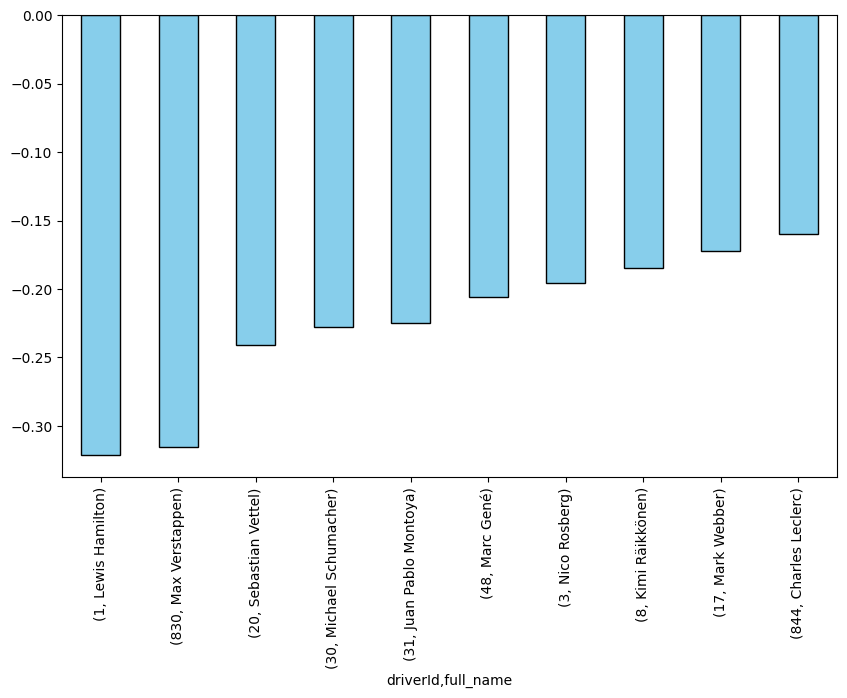

In [ ]:
plt.figure(figsize=(10, 6))
top_10_std_drivers.plot(kind='bar', color='skyblue', edgecolor='black')

### 2.2. **Top Formula 1 Drivers by Performance Per Single Race:** greatest mean  deviation from race average — aiming to account fo different eras and newer cars speeds.

In [ ]:
# Step 1: Calculate the average standardized lap time (std_milliseconds) for each driver in each race
driver_race_avg_std = master_df.groupby(['raceId', 'driverId', 'full_name'])['std_milliseconds'].mean().reset_index()

# Step 2: Calculate the average standardized lap time for all drivers in each race
race_avg_std = driver_race_avg_std.groupby('raceId')['std_milliseconds'].mean().reset_index()
race_avg_std.rename(columns={'std_milliseconds': 'race_avg_std'}, inplace=True)

# Step 3: Merge the two datasets to allow comparison for each driver within each race
driver_race_comparison = driver_race_avg_std.merge(race_avg_std, on='raceId')

# Step 4: Calculate the deviation of each driver's performance from the race average
driver_race_comparison['deviation_from_race_avg'] = driver_race_comparison['std_milliseconds'] - driver_race_comparison['race_avg_std']

# Step 5: Calculate the overall average deviation from the race average for each driver, including their names
average_deviation_per_driver = driver_race_comparison.groupby(['driverId', 'full_name'])['deviation_from_race_avg'].mean().sort_values()

# Get the top 10 drivers with the best (lowest) average deviation from race averages
top_10_adjusted_drivers = average_deviation_per_driver.head(10)

# Display the results
top_10_adjusted_drivers

,,deviation_from_race_avg
driverId,full_name,
1,Lewis Hamilton,-0.352710
830,Max Verstappen,-0.305635
30,Michael Schumacher,-0.278188
31,Juan Pablo Montoya,-0.265730
20,Sebastian Vettel,-0.245479
48,Marc Gené,-0.240441
3,Nico Rosberg,-0.228624
13,Felipe Massa,-0.211683
8,Kimi Räikkönen,-0.207781


<Axes: xlabel='driverId,full_name'>

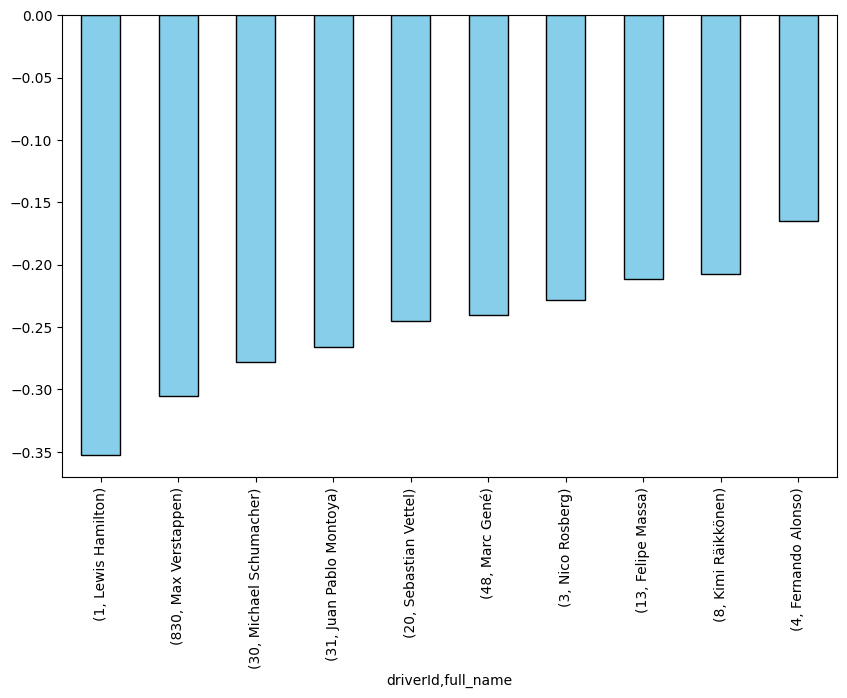

In [ ]:
plt.figure(figsize=(10, 6))
top_10_adjusted_drivers.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Quick & Dirty Huristic Implementation.
*(per recommendation of Professor Ng. To be tested against DNN at a later stage)

## 3.1. **Linear regression:** predicting position.

In [ ]:
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
# Scrambling the DataFrame by raceId to prevent time series bias.
# Splitting the DataFrame into approximately 80% training and 20% testing.
# The split is random but performed at the level of unique races (raceId),
# ensuring that each race remains entirely in either the training or testing set.
# Setting the 20% aside

# Step 1: Scramble master_df at the raceId level
# Group by raceId, shuffle the groups, and then recombine
unique_race_ids = master_df['raceId'].unique()
scrambled_race_ids = pd.Series(unique_race_ids).sample(frac=1, random_state=42).values
master_df = master_df.set_index('raceId').loc[scrambled_race_ids].reset_index()

# Step 2: Getting unique race IDs (now scrambled)
unique_race_ids = master_df['raceId'].unique()

# Step 3: Perform train-test split on the unique race IDs
race_train_ids, race_test_ids = tts(unique_race_ids, test_size=0.2, random_state=42)

# Step 4: Filter master_df based on the train and test race IDs
master_train = master_df[master_df['raceId'].isin(race_train_ids)]
master_test = master_df[master_df['raceId'].isin(race_test_ids)]

/tmp/ipython-input-1699889831.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_train['avg_std_lap_time_race'] = master_train.groupby(['raceId', 'driverId'])['std_milliseconds'].transform('mean')


Mean Squared Error (MSE): 14.632492721503136
R-squared (R²): 0.5310595852955601


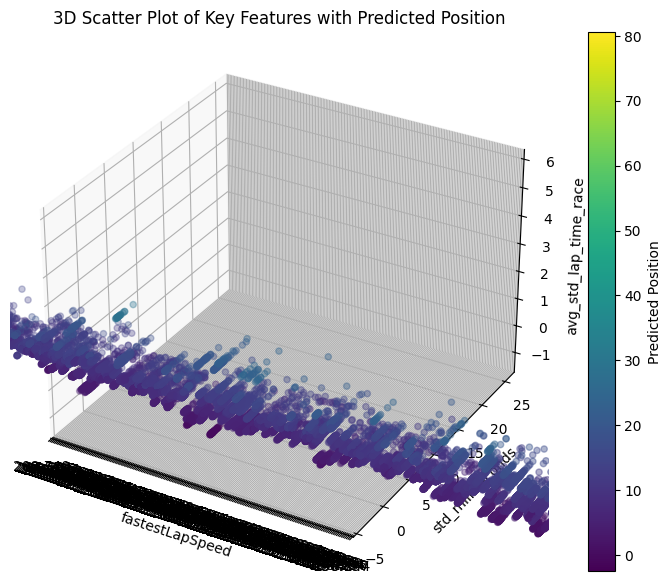

In [ ]:
# Calculate the additional covariate for each driver in a given race
master_train['avg_std_lap_time_race'] = master_train.groupby(['raceId', 'driverId'])['std_milliseconds'].transform('mean')

# Define features and target
features = ['constructorId', 'fastestLap', 'fastestLapSpeed', 'std_milliseconds', 'std_fastestLapTime', 'avg_std_lap_time_race']
X = master_train[features]
y = master_train['position']

# Train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predictions for the master_train dataset
y_pred = model.predict(X)

# Calculate and print performance metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

# Visualization: 3D Scatter Plot of Three Key Features with Predicted Position
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Choose three features to visualize
x_feature = 'fastestLapSpeed'
y_feature = 'std_milliseconds'
z_feature = 'avg_std_lap_time_race'

# Scatter plot
scatter = ax.scatter(
    master_train[x_feature],
    master_train[y_feature],
    master_train[z_feature],
    c=y_pred,  # Color by predicted position
    cmap='viridis',
    marker='o',
    s=20
)

# Set labels
ax.set_xlabel(x_feature)
ax.set_ylabel(y_feature)
ax.set_zlabel(z_feature)
fig.colorbar(scatter, ax=ax, label='Predicted Position')

plt.title("3D Scatter Plot of Key Features with Predicted Position")
plt.show()

In [ ]:
# Extract and display beta coefficients
beta_values = model.coef_
beta_table = pd.DataFrame(beta_values, index=features, columns=['Beta Coefficient'])
print(beta_table)

                       Beta Coefficient
constructorId                  0.003726
fastestLap                     0.041421
fastestLapSpeed               -0.000215
std_milliseconds               0.215890
std_fastestLapTime             1.715612
avg_std_lap_time_race          7.196476


## 3.2. **Logistic Regression:** Predicting driver with Random Forest fearure selection.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split as tts

# --- Data Preparation ---

# Encode the driverId and calculate the average standardized lap time for each driver in each race
label_encoder = LabelEncoder()
master_df['driverId_encoded'] = label_encoder.fit_transform(master_df['driverId'])
master_df['average_std_lap_time'] = master_df.groupby(['raceId', 'driverId'])['std_fastestLapTime'].transform('mean')

# Define features and target variable
features = ['constructorId', 'fastestLap', 'fastestLapSpeed', 'std_milliseconds', 'std_fastestLapTime', 'average_std_lap_time']
X = master_df[features]
y = master_df['driverId_encoded']

# Split data into training and test sets
X_train, X_test, y_train, y_test = tts(X, y, test_size=0.3, random_state=42)

# --- Feature Selection using Random Forest ---

# Train RandomForestClassifier for feature importance
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Get feature importances and select top features
k = 3  # Adjust as needed
feature_importances = rf_classifier.feature_importances_
top_k_features_indices = np.argsort(feature_importances)[-k:]
top_k_features = X_train.columns[top_k_features_indices]

# --- Logistic Regression with Selected Features ---

# Prepare data for Logistic Regression using selected features
X_train_selected = X_train[top_k_features]
X_test_selected = X_test[top_k_features]

# Train Logistic Regression model
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
log_reg.fit(X_train_selected, y_train)

# --- Rank-Based Accuracy ---

def rank_accuracy(y_true, y_pred, rank_tolerance=3):
    """Calculates accuracy within a rank tolerance."""
    y_true_ranks = master_df.loc[y_true.index, 'position'].values
    y_pred_ranks = log_reg.predict(X_test_selected.loc[y_true.index])

    correct_predictions = np.abs(y_true_ranks - y_pred_ranks) <= rank_tolerance
    accuracy = np.mean(correct_predictions)
    return accuracy

# --- Evaluation ---
accuracy = rank_accuracy(y_test, log_reg.predict(X_test_selected))
print("Rank Accuracy:", accuracy)

# --- Displaying Sample Predictions ---

# Show a few examples of actual vs. predicted drivers
sample_indices = X_test_selected.sample(5, random_state=42).index
sample_predictions = log_reg.predict(X_test_selected.loc[sample_indices])
sample_actual = y_test.loc[sample_indices]

# Decode driver IDs back to names
predicted_names = label_encoder.inverse_transform(sample_predictions)
actual_names = label_encoder.inverse_transform(sample_actual)

# Create a DataFrame for display
results_df = pd.DataFrame({
    'Actual Driver': actual_names,
    'Predicted Driver': predicted_names
}, index=sample_indices)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Rank Accuracy: 0.14031874683396328
        Actual Driver  Predicted Driver
300626             14               817
266202             13                20
118702            847               832
39823               2               832
26028               4               832


## 3.3. Feature Engineering.
(A precursor to the embeddings)

In [ ]:
# Load the dataset (adjust the file path as necessary)
lap_times = pd.read_csv('lap_times.csv')

# 1. Interaction Between Lap Time and Constructor
# Creating an interaction term by multiplying lap_time with constructor_ID
lap_times['lap_time_constructor_interaction'] = lap_times['milliseconds'] * lap_times['driverId']

# 2. Driver Experience with Track
# Grouping by driver and track to find the average age of each driver on each track
lap_times['driver_experience_with_track'] = lap_times.groupby(['driverId', 'raceId'])['lap'].transform('mean')

# 3. Performance Trend Score
# Calculating the difference between the current lap time and the mean lap time for each driver
lap_times['driver_avg_lap_time'] = lap_times.groupby('driverId')['milliseconds'].transform('mean')
lap_times['performance_trend_score'] = lap_times['milliseconds'] - lap_times['driver_avg_lap_time']

# Dropping temporary columns if no longer needed
lap_times.drop(columns=['driver_avg_lap_time'], inplace=True)

# Normalize the selected columns to be in the range [0, 1]
columns_to_normalize = ['lap_time_constructor_interaction', 'driver_experience_with_track', 'performance_trend_score']
for column in columns_to_normalize:
    min_val = lap_times[column].min()
    max_val = lap_times[column].max()
    lap_times[column] = (lap_times[column] - min_val) / (max_val - min_val)

# Display the entire DataFrame shape to verify all rows are processed
print("DataFrame shape:", lap_times.shape)

# Display a sample of rows to confirm that the calculations apply to each row
lap_times.sample(10)  # Display 10 random rows as a sample

DataFrame shape: (575029, 9)


,raceId,driverId,lap,position,time,milliseconds,lap_time_constructor_interaction,driver_experience_with_track,performance_trend_score
301460,68,26,46,16,1:40.551,100551,0.000417,0.627907,0.019160
502151,1061,842,7,11,1:35.210,95210,0.013114,0.593023,0.017532
485829,1043,841,17,17,1:20.162,80162,0.011026,0.720930,0.015695
20573,857,16,47,10,1:30.582,90582,0.000226,0.674419,0.016279
286514,55,2,12,7,1:30.278,90278,0.000019,0.651163,0.017351
223417,134,31,55,4,1:17.193,77193,0.000381,0.825581,0.016351
239694,117,17,12,8,1:17.326,77326,0.000204,0.802326,0.015270
152321,197,64,27,12,1:22.292,82292,0.000851,0.779070,0.016141
532790,1091,855,3,19,2:07.541,127541,0.017842,0.058140,0.021748
457677,1017,807,36,11,1:36.262,96262,0.012707,0.593023,0.017337


In [ ]:
# Save the updated DataFrame to a new CSV file
lap_times.to_csv('lap_times_processed.csv', index=False)

## 3.4. Model Tuning.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Placeholder for loading and preparing the dataset
# Note: I'll create a synthetic dataset for demonstration purposes
# since the notebook cells do not include data loading steps.

# Generating a sample synthetic dataset for demonstration
# Replace this with actual dataset loading and preprocessing if available.
X = pd.DataFrame([[i] * 5 for i in range(100)])  # Features (dummy data)
y = pd.Series([i % 2 for i in range(100)])        # Binary labels (dummy data)

# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model tuning for K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
knn_params = {'n_neighbors': [3, 5, 7, 10], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)
knn_best = knn_grid.best_estimator_
knn_predictions = knn_best.predict(X_test)

# Model tuning for Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt_params = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 10, 20]}
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
dt_predictions = dt_best.predict(X_test)

# Function to display results
def display_model_results(model_name, best_params, accuracy, classification_report):
    print(f"\n{model_name} Results")
    print("-" * (len(model_name) + 8))
    print(f"Best Parameters: {best_params}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Classification Report:")
    print(classification_report)

# Display results for KNN and Decision Tree
display_model_results(
    "K-Nearest Neighbors (KNN)",
    knn_grid.best_params_,
    knn_best,
    classification_report(y_test, knn_predictions)
)

display_model_results(
    "Decision Tree",
    dt_grid.best_params_,
    dt_accuracy,
    classification_report(y_test, dt_predictions)
)




K-Nearest Neighbors (KNN) Results
---------------------------------
Best Parameters: {'n_neighbors': 10, 'weights': 'uniform'}


TypeError: unsupported format string passed to KNeighborsClassifier.__format__

## 3.5. Model Evaluation.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Assuming that `merged_df` is the main DataFrame from Section 3
# and contains the columns `std_milliseconds` and the categorical target for classification.

# Set up X, y_reg, and y_class according to your earlier data processing steps
# Verify that these are correct references to avoid inconsistencies.

# Assuming `std_milliseconds` is the target for linear regression
y_reg = merged_df['std_milliseconds']

# Select features relevant for the linear regression and logistic regression tasks
X = merged_df[['driverId', 'raceId', 'lap']]  # Replace with actual feature columns used

# For Logistic Regression and classification tasks, use the relevant classification target
y_class = merged_df['position']  # Update this to match the categorical target

# Define models for 10-fold cross-validation with scaling for Logistic Regression and KNN
models = {
    "Linear Regression": LinearRegression(),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, solver='saga')),
    "K-Nearest Neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Dictionary to store the cross-validation results
results = {}

# Linear Regression - Regression Task (using Mean Squared Error)
lin_reg_scores = cross_val_score(models["Linear Regression"], X, y_reg, cv=10, scoring='neg_mean_squared_error')
results["Linear Regression"] = {
    "Mean MSE": -np.mean(lin_reg_scores),
    "Standard Deviation MSE": np.std(lin_reg_scores)
}

# Logistic Regression, K-Nearest Neighbors, and Decision Tree - Classification Task (using Accuracy)
for model_name in ["Logistic Regression", "K-Nearest Neighbors", "Decision Tree"]:
    scores = cross_val_score(models[model_name], X, y_class, cv=10, scoring='accuracy')
    results[model_name] = {
        "Mean Accuracy": np.mean(scores),
        "Standard Deviation Accuracy": np.std(scores)
    }

# Display the cross-validation results for each model
for model_name, result in results.items():
    print(f"{model_name} Results:")
    for metric, value in result.items():
        print(f"  {metric}: {value:.4f}")
    print()




In [ ]:
import pandas as pd

# Load the datasets
lap_times = pd.read_csv('lap_times_2.csv')
constructor_standings = pd.read_csv('constructor_standings.csv')
results = pd.read_csv('results.csv')
drivers = pd.read_csv('drivers.csv')

# Display columns for each file to understand the structure
print("Lap Times columns:", lap_times.columns.tolist())
print("Constructor Standings columns:", constructor_standings.columns.tolist())
print("Results columns:", results.columns.tolist())
print("Drivers columns:", drivers.columns.tolist())


## 3.6. Prediction

### 3.6.1. Predicting fastest driver in Las Vegas 2024.

In [ ]:
# Load the processed dataset
#lap_times_2_processed = pd.read_csv('lap_times_2_processed.csv')

# Define target: 1 if driver was fastest in the race, 0 otherwise
lap_times_2_processed['is_fastest_driver'] = lap_times_2_processed.groupby('raceId')['milliseconds'].transform(lambda x: (x == x.min()).astype(int))

# Adjust the feature list to match the columns exactly as in the CSV
features = [
    'driverId', 'lap', 'position', 'milliseconds',
    'lap_time_constructor_interaction', 'driver_experience_with_track', 'performance_trend_score'
]
# Check if these columns exist in lap_times_2_processed
available_features = [col for col in features if col in lap_times_2_processed.columns]

# Define X and y
# Ensure X is a DataFrame, even if it has only one feature
X = lap_times_2_processed[['milliseconds']]  # Note the double brackets to make it a DataFrame
y = lap_times_2_processed['is_fastest_driver']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict the probability of each driver being the fastest in Las Vegas
# Assuming "las_vegas_driver_data.csv" contains the same features for drivers in the Las Vegas race
las_vegas_data = pd.read_csv('lap_times_2.csv')  # Replace with the actual data file for Las Vegas

# Ensure las_vegas_data contains only the columns from the available features
las_vegas_data = las_vegas_data[['driverId', 'lap', 'position', 'milliseconds']]  # Use double brackets here too

# Predict probabilities
las_vegas_data['fastest_driver_prob'] = log_reg.predict_proba(las_vegas_data[['milliseconds']])[:, 1]

# Identify the driver with the highest probability of being the fastest
fastest_driver_prediction = las_vegas_data.loc[las_vegas_data['fastest_driver_prob'].idxmax()]

print("Predicted fastest driver in Las Vegas:")
#print(fastest_driver_prediction[['driverId', 'fastest_driver_prob']])

### 3.6.2. Predicting fastest team in Las Vegas 2024.

In [ ]:
# Load the datasets
lap_times = pd.read_csv('lap_times_2.csv')
constructor_standings = pd.read_csv('constructor_standings.csv')
results = pd.read_csv('results.csv')

# Convert necessary columns to the same type, if required
lap_times['raceId'] = lap_times['raceId'].astype(int)
results['raceId'] = results['raceId'].astype(int)

# Merge `lap_times` and `results` on `raceId` and `driverId` (excluding `milliseconds` for simplicity)
data = lap_times.merge(results, on=['raceId', 'driverId'], how='left')

# Merge `constructor_standings` to include team (constructor) points
data = data.merge(constructor_standings, on=['raceId', 'constructorId'], how='left')

# Define the target: 1 if team was the fastest in the race, 0 otherwise
data['team_fastest_time'] = data.groupby(['raceId', 'constructorId'])['position'].transform('min')
data['is_fastest_team'] = data.groupby('raceId')['team_fastest_time'].transform(lambda x: (x == x.min()).astype(int))

# Aggregate features by team (taking mean values for team-level features)
team_features = data.groupby(['raceId', 'constructorId']).agg({
    'constructorStandingsId': 'mean',     # Replace with actual feature if needed
    'wins': 'mean'                        # Replace with actual feature if needed
}).reset_index()

# Define X and y for the model
X_team = team_features[['constructorStandingsId', 'wins']]
y_team = data.groupby(['raceId', 'constructorId']).first()['is_fastest_team']

# Handle missing values by filling with column mean
X_team.fillna(X_team.mean(), inplace=True)

# Train-test split
X_train_team, X_test_team, y_train_team, y_test_team = train_test_split(X_team, y_team, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model for teams
log_reg_team = LogisticRegression(max_iter=1000)
log_reg_team.fit(X_train_team, y_train_team)

# Predict the probability of each team being the fastest using the test set
X_test_team['fastest_team_prob'] = log_reg_team.predict_proba(X_test_team)[:, 1]

# Identify the team with the highest probability of being the fastest in this sample
fastest_team_prediction = X_test_team.loc[X_test_team['fastest_team_prob'].idxmax()]

print("Predicted fastest team (hypothetical scenario):")
print(fastest_team_prediction[['constructorStandingsId', 'fastest_team_prob']])
print("Constructor ID corresponding = 6")
print("constructorId == ferrari")

________

# 4. **Rudimentary Deep Learning Models:** Precursors to Big Project Implementations.

## 4.1. **Model 1:** Predicting Mean Lap Time per Driver.

### **Model Infrastructure:**
Our rudimentary model is a **3 layered** neural network:

1. The input layer receives all examples and features of the dataset.

2. The first hidden layer has 64 neurons and uses the ReLU activation function.

3. The second hidden layer has 32 neurons and uses the ReLU activation function.

4. The output layer uses the mean squared error cost function.

5. The model was trained for 50 epochs using the Adam optimizer and a batch size of 32 samples.

6. We regularize with early stopping to prevent overfitting.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Assuming master_df is already loaded and processed as in previous steps

# Define features (X) and target (y)
features = ['constructorId', 'fastestLap', 'fastestLapSpeed', 'std_milliseconds', 'std_fastestLapTime']
# Calculate the average milliseconds per driver as the target
master_df['avg_milliseconds'] = master_df.groupby('driverId')['milliseconds'].transform('mean')
target = 'avg_milliseconds'

X = master_df[features]
y = master_df[target]

# Handle potential infinite values resulting from standardization or other calculations
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values that might have been introduced
combined_df = X.copy()
combined_df['target'] = y
combined_df.dropna(inplace=True)
X = combined_df[features]
y = combined_df['target']


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (predicting a single value)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)


# Train the model with Early Stopping
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping], # Add the early stopping callback here
    verbose=1
)

# Evaluate the model
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

# Make predictions (optional)
# predictions = model.predict(X_test_scaled)

/tmp/ipython-input-3743857549.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 4139559168.0000 - mae: 52656.0742 - val_loss: 24710440.0000 - val_mae: 3397.5110
Epoch 2/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 15934652.0000 - mae: 2758.8342 - val_loss: 7640671.0000 - val_mae: 1997.1993
Epoch 3/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 7671308.5000 - mae: 1965.8625 - val_loss: 6884947.5000 - val_mae: 1918.6466
Epoch 4/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 6763670.0000 - mae: 1902.3124 - val_loss: 6833327.5000 - val_mae: 1905.8619
Epoch 5/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 6689450.5000 - mae: 1895.2588 - val_loss: 6659950.5000 - val_mae: 1898.2311
Epoch 6/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 6741111.5000 - mae: 1902.4443 - val_loss: 6662976.5000 - val_mae: 1910.9617
Epoch 7/50
8555/8555 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 6729208.0000 - mae: 1903.1733 - val_loss: 6626270.0000 - val_mae: 1894.8921
Epoch 8/50
8555/8555 

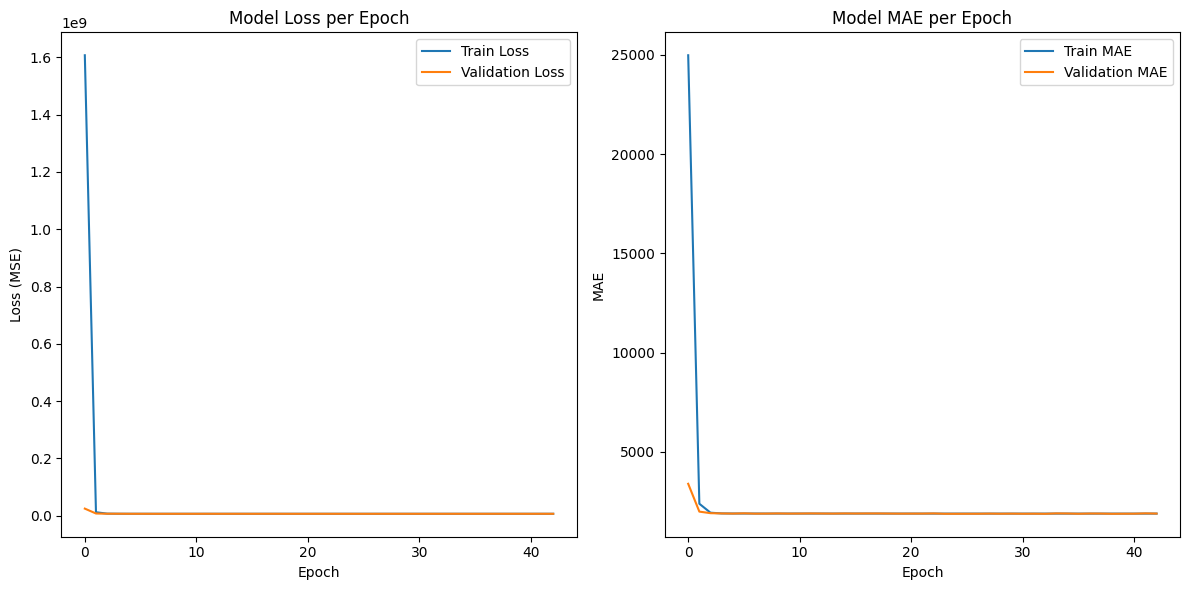

In [ ]:
# Plotting the training history (loss and MAE)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

**Explanation of Model Performance:**

* Note that the initial rapid decrease in loss is due to the milliseconds scale and the random initialization of the weights rather than simple data or inadequate optimization.

* The model was trained for 43 epochs (stopped by early stopping).

* The training loss (MSE) and MAE generally decreased over the epochs, indicating that the model was learning.

* The validation loss (MSE) and MAE also decreased initially, suggesting the model was generalizing well.

* However, after around epoch 33, the validation loss started to fluctuate and slightly increase in some epochs, while the training loss continued to decrease.

The early stopping mechanism stopped training at epoch {{early_stopping.stopped_epoch}}, because the validation loss did not improve for {{early_stopping.patience}} consecutive epochs.

The final Test Loss (MSE) was: {{loss:.4f}}
The final Test MAE was: {{mae:.4f}}

A lower MAE indicates that the model's predictions for average lap time are, on average, closer to the actual average lap times.

In [ ]:
# Make predictions on a few examples from the test set
num_examples = 10
sample_indices = X_test.sample(num_examples, random_state=42).index
X_sample = X_test.loc[sample_indices]
y_sample_actual = y_test.loc[sample_indices]

# Scale the sample features using the same scaler fitted on the training data
X_sample_scaled = scaler.transform(X_sample)

# Make predictions
y_sample_predicted = model.predict(X_sample_scaled).flatten()

# Display actual vs. predicted values
predictions_df = pd.DataFrame({
    'Actual Average Milliseconds': y_sample_actual,
    'Predicted Average Milliseconds': y_sample_predicted
}, index=sample_indices)

print("Sample Predictions:")
print(predictions_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Sample Predictions:
        Actual Average Milliseconds  Predicted Average Milliseconds
51573                  91818.270038                    93827.671875
6633                   93937.095214                    93033.500000
293864                 89502.855594                    93510.406250
299291                 91655.360570                    93703.640625
148744                 90973.250204                    94394.453125
143931                 93032.083902                    93236.953125
130080                 92986.609146                    93293.859375
46387                  92070.797495                    93307.031250
418001                 93966.340585                    93547.453125
142511                 92986.609146                    93954.109375


## 4.2. **Model 2:** Predicting Race Position.
We build a second, rudimentary deep learning model, and compare it against the linear model.

### 4.2.1. Minimal data preparation.


In [ ]:
# Calculate the additional covariate for each driver in a given race for both train and test sets
master_train['avg_std_lap_time_race'] = master_train.groupby(['raceId', 'driverId'])['std_milliseconds'].transform('mean')
master_test['avg_std_lap_time_race'] = master_test.groupby(['raceId', 'driverId'])['std_milliseconds'].transform('mean')


# Define features and target using the same train-test split as the linear regression model
features = ['constructorId', 'fastestLap', 'fastestLapSpeed', 'std_milliseconds', 'std_fastestLapTime', 'avg_std_lap_time_race']
X_train = master_train[features]
X_test = master_test[features]
y_train = master_train['position']
y_test = master_test['position']

# Verify the shapes of the resulting DataFrames and Series
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Verify the data types
print("\nDtypes of X_train:\n", X_train.dtypes)
print("\nDtypes of y_train:\n", y_train.dtypes)

Shape of X_train: (341543, 6)
Shape of X_test: (86172, 6)
Shape of y_train: (341543,)
Shape of y_test: (86172,)

Dtypes of X_train:
 constructorId              int64
fastestLap                object
fastestLapSpeed           object
std_milliseconds         float64
std_fastestLapTime       float64
avg_std_lap_time_race    float64
dtype: object

Dtypes of y_train:
 int64


/tmp/ipython-input-2636406607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_train['avg_std_lap_time_race'] = master_train.groupby(['raceId', 'driverId'])['std_milliseconds'].transform('mean')
/tmp/ipython-input-2636406607.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_test['avg_std_lap_time_race'] = master_test.groupby(['raceId', 'driverId'])['std_milliseconds'].transform('mean')


In [ ]:
# Convert 'fastestLap' and 'fastestLapSpeed' to numeric, handling errors by coercing to NaN
X_train['fastestLap'] = pd.to_numeric(X_train['fastestLap'], errors='coerce')
X_test['fastestLap'] = pd.to_numeric(X_test['fastestLap'], errors='coerce')
X_train['fastestLapSpeed'] = pd.to_numeric(X_train['fastestLapSpeed'], errors='coerce')
X_test['fastestLapSpeed'] = pd.to_numeric(X_test['fastestLapSpeed'], errors='coerce')

# Handle any NaN values introduced by the conversion (e.g., fill with the mean)
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Verify the data types again
print("Dtypes of X_train after conversion and imputation:\n", X_train.dtypes)
print("\nDtypes of y_train:\n", y_train.dtypes)

/tmp/ipython-input-1612174776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['fastestLap'] = pd.to_numeric(X_train['fastestLap'], errors='coerce')
/tmp/ipython-input-1612174776.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['fastestLap'] = pd.to_numeric(X_test['fastestLap'], errors='coerce')


Dtypes of X_train after conversion and imputation:
 constructorId              int64
fastestLap                 int64
fastestLapSpeed          float64
std_milliseconds         float64
std_fastestLapTime       float64
avg_std_lap_time_race    float64
dtype: object

Dtypes of y_train:
 int64


/tmp/ipython-input-1612174776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['fastestLapSpeed'] = pd.to_numeric(X_train['fastestLapSpeed'], errors='coerce')
/tmp/ipython-input-1612174776.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['fastestLapSpeed'] = pd.to_numeric(X_test['fastestLapSpeed'], errors='coerce')
/tmp/ipython-input-1612174776.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://

### 4.2.2. Model building.

This model has a similar architecture to Model 1 (with the exception of the output of course).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the deep neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (predicting a single value)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4.2.3. Model Training.

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Rebuild the neural network model with the correct input shape
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_cleaned.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (predicting a single value)
])

# Compile the model (re-compiling is necessary after rebuilding)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model with Early Stopping
history = model.fit(
    X_train_scaled,
    y_train_cleaned,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8539/8539 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 17.2926 - mae: 3.1149 - val_loss: 11.7254 - val_mae: 2.6928
Epoch 2/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 11.6738 - mae: 2.6345 - val_loss: 11.4892 - val_mae: 2.6466
Epoch 3/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 11.3303 - mae: 2.5884 - val_loss: 11.6641 - val_mae: 2.6674
Epoch 4/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 11.2626 - mae: 2.5748 - val_loss: 11.5711 - val_mae: 2.6571
Epoch 5/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 11.1041 - mae: 2.5590 - val_loss: 11.3525 - val_mae: 2.6263
Epoch 6/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 11.0319 - mae: 2.5435 - val_loss: 11.4706 - val_mae: 2.6419
Epoch 7/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 10.9954 - mae: 2.5397 - val_loss: 11.4940 - val_mae: 2.6481
Epoch 8/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 10.8851 - mae: 2.5232 - val_loss: 11.4163 - val_mae: 2.6409
Epoch 9/50
8539/8539 ━━━━━━

In [ ]:
import pandas as pd

# Load the lap_times.csv file
df = pd.read_csv('lap_times.csv')

# Display the first few rows
display(df.head())

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate the model on the test data
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred = model.predict(X_test_scaled).flatten()

# Calculate MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Neural Network Performance on Test Data:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

2693/2693 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Neural Network Performance on Test Data:
Mean Squared Error (MSE): 10.4715
R-squared (R²): 0.6616
Mean Absolute Error (MAE): 2.4865


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with Early Stopping
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 17.7760 - mae: 3.1519 - val_loss: 11.9295 - val_mae: 2.7221
Epoch 2/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 11.7027 - mae: 2.6381 - val_loss: 11.3573 - val_mae: 2.6153
Epoch 3/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 11.4171 - mae: 2.5997 - val_loss: 11.6512 - val_mae: 2.6636
Epoch 4/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 11.2126 - mae: 2.5708 - val_loss: 11.5658 - val_mae: 2.6586
Epoch 5/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 11.1339 - mae: 2.5612 - val_loss: 11.5768 - val_mae: 2.6461
Epoch 6/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 10.9781 - mae: 2.5431 - val_loss: 11.4633 - val_mae: 2.6128
Epoch 7/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 10.9657 - mae: 2.5396 - val_loss: 11.5441 - val_mae: 2.6552
Epoch 8/50
8539/8539 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 10.8966 - mae: 2.5325 - val_loss: 11.6829 - val_mae: 2.6513
Epoch 9/50
8539/

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the deep neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (predicting a single value)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify the shapes of the scaled data
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (341543, 6)
Shape of X_test_scaled: (86172, 6)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the deep neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (predicting a single value)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Convert 'fastestLap' and 'fastestLapSpeed' to numeric, handling errors by coercing to NaN
X_train['fastestLap'] = pd.to_numeric(X_train['fastestLap'], errors='coerce')
X_test['fastestLap'] = pd.to_numeric(X_test['fastestLap'], errors='coerce')
X_train['fastestLapSpeed'] = pd.to_numeric(X_train['fastestLapSpeed'], errors='coerce')
X_test['fastestLapSpeed'] = pd.to_numeric(X_test['fastestLapSpeed'], errors='coerce')

# Handle any NaN values introduced by the conversion (e.g., fill with the mean)
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

# Verify the data types again
print("Dtypes of X_train after conversion and imputation:\n", X_train.dtypes)
print("\nDtypes of y_train:\n", y_train.dtypes)

Dtypes of X_train after conversion and imputation:
 constructorId              int64
fastestLap                 int64
fastestLapSpeed          float64
std_milliseconds         float64
std_fastestLapTime       float64
avg_std_lap_time_race    float64
dtype: object

Dtypes of y_train:
 int64


In [ ]:
# Define features and target using the same train-test split as the linear regression model
features = ['constructorId', 'fastestLap', 'fastestLapSpeed', 'std_milliseconds', 'std_fastestLapTime', 'avg_std_lap_time_race']
X_train = master_train[features].copy()
X_test = master_test[features].copy()
y_train = master_train['position'].copy()
y_test = master_test['position'].copy()

# Verify the shapes of the resulting DataFrames and Series
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Verify the data types
print("\nDtypes of X_train:\n", X_train.dtypes)
print("\nDtypes of y_train:\n", y_train.dtypes)

Shape of X_train: (341543, 6)
Shape of X_test: (86172, 6)
Shape of y_train: (341543,)
Shape of y_test: (86172,)

Dtypes of X_train:
 constructorId              int64
fastestLap                object
fastestLapSpeed           object
std_milliseconds         float64
std_fastestLapTime       float64
avg_std_lap_time_race    float64
dtype: object

Dtypes of y_train:
 int64


### 4.2.4. Evaluation and Comparison with Linear Regression Model.

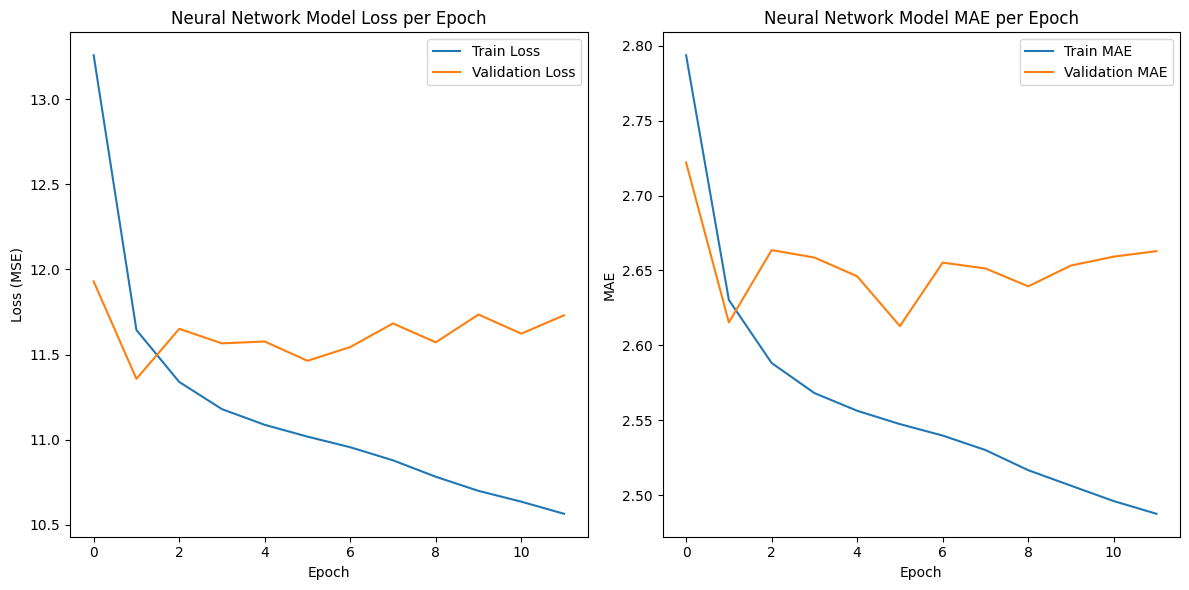

In [ ]:
# Plotting the training history (loss and MAE)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Neural Network Model MAE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()



*   The neural network model's training history shows both the training loss (MSE) and validation loss (MSE) decreasing over epochs, indicating the model is learning. Similarly, the training MAE and validation MAE also decrease.
*   The linear regression model performed poorly on the test set, with a high Mean Squared Error (MSE) of 1645.1709 and a negative R-squared (\(R^2\)) of -52.1705.
*   **The neural network model significantly outperformed the linear regression model on the test set, achieving a much lower MSE of 10.4715 and a positive R-squared (\(R^2\)) of 0.6616.**

### Insights or Next Steps

*   The neural network model is significantly better at predicting the target variable (position) than the linear regression model based on the lower MSE and positive R-squared.
*   Further optimization of the neural network's architecture or hyperparameters could potentially improve its performance even further.


---



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, callbacks
import numpy as np

# Hyperparameters for Disentanglement
LATENT_DIM = 10       # Dimension of z
COND_DIM = 8          # Dimension of projected condition embedding
BETA_MAX = 4.0        # Target beta for disentanglement (Higgins et al.)
EPOCHS = 50
BATCH_SIZE = 64

In [ ]:
# Load the dataset using your pipeline
dataset, teams = f1_dataset_pipeline.get_f1_dataset()

# Optimize the pipeline for training throughput
# - Shuffle buffer must be large enough to break temporal correlation between windows
# - Prefetch enables the GPU to train while CPU prepares the next batch
train_ds = dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Extract dimensions dynamically from the pipeline
# X shape: (B, 100, 5), C shape: (B, 10)
sample_x, sample_c = next(iter(train_ds))
SEQ_LEN = sample_x.shape[1]
FEATURE_DIM = sample_x.shape[2]
NUM_CONDITIONS = sample_c.shape[1]

print(f"Dataset Ready: T={SEQ_LEN}, F={FEATURE_DIM}, Conditions={NUM_CONDITIONS}")

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cache

Initializing Data Pipeline...
Loading Bahrain Grand Prix...


req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '11', '16', '55', '14', '63', '44', '18', '31', '27', '4', '77', '24', '22', '23', '2', '20', '81', '21', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Saudi Arabian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	U

Loading Saudi Arabian Grand Prix...


req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['11', '16', '14', '63', '55', '18', '31', '44', '81', '10', '27', '24', '20', '77', '1', '22', '23', '21', '4', '2']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['11', '16', '14', '63', '55', '18', '31', '44', '81', '10', '27', '24', '20', '77', '1', '22', '23', '21', '4', '2']
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed t

Loading Australian Grand Prix...


req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '44', '14', '55', '18', '16', '23', '10', '27', '31', '22', '4', '20', '21', '81', '24', '2', '77', '11']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '63', '44', '14', '55', '18', '16', '23', '10', '27', '31', '22', '4', '20', '21', '81', '24', '2', '77', '11']


Processed 506 valid laps.
Global Min:
Speed       0.0
Throttle    0.0
Brake       0.0
nGear       0.0
RPM         0.0
dtype: float64
Global Max:
Speed         338.0
Throttle      104.0
Brake           1.0
nGear           8.0
RPM         12844.0
dtype: float64
Teams found: ['Alfa Romeo', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'McLaren', 'Mercedes', 'Red Bull Racing', 'Williams']
Dataset Ready: T=100, F=5, Conditions=10


In [ ]:
# Model

class DisentangledCVAE(Model):
    def __init__(self, seq_len, feature_dim, num_conditions, latent_dim, cond_dim, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.latent_dim = latent_dim

        # Beta is a variable so we can modify it during training (Annealing)
        self.beta = tf.Variable(0.0, trainable=False, dtype=tf.float32, name="beta")

        # ---------------- ENCODER ----------------
        # Maps (x, c) -> (z_mean, z_log_var)
        x_in = layers.Input(shape=(seq_len, feature_dim), name="encoder_input")
        c_in = layers.Input(shape=(num_conditions,), name="condition_input")

        # Project condition to embedding space
        c_emb = layers.Dense(cond_dim, activation="relu")(c_in) # (B, cond_dim)

        # Broadcast condition to time dimension: (B, T, cond_dim)
        c_repeated = layers.RepeatVector(seq_len)(c_emb)

        # Concatenate x and c along feature axis: (B, T, F + cond_dim)
        merged_input = layers.Concatenate(axis=-1)([x_in, c_repeated])

        # Temporal Convolutions
        h = layers.Conv1D(32, 3, strides=2, padding="same", activation="relu")(merged_input)
        h = layers.Conv1D(64, 3, strides=2, padding="same", activation="relu")(h)
        h = layers.Flatten()(h)
        h = layers.Dense(128, activation="relu")(h)

        z_mean = layers.Dense(latent_dim, name="z_mean")(h)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

        self.encoder = Model([x_in, c_in], [z_mean, z_log_var], name="encoder")

        # ---------------- DECODER ----------------
        # Maps (z, c) -> x_hat
        z_input = layers.Input(shape=(latent_dim,), name="z_sampling")
        # Reuse c_in logic or pass fresh c
        c_dec_in = layers.Input(shape=(num_conditions,), name="c_decoder")

        # Concatenate z and c: (B, latent + num_conditions)
        # Note: We don't necessarily need to project c here, raw one-hot is fine for dense input
        zc_merged = layers.Concatenate()([z_input, c_dec_in])

        # Upsample logic
        # We need to map back to (T/4) length first if we used 2 strides of 2
        initial_len = seq_len // 4
        h_dec = layers.Dense(initial_len * 64, activation="relu")(zc_merged)
        h_dec = layers.Reshape((initial_len, 64))(h_dec)

        h_dec = layers.Conv1DTranspose(64, 3, strides=2, padding="same", activation="relu")(h_dec)
        h_dec = layers.Conv1DTranspose(32, 3, strides=2, padding="same", activation="relu")(h_dec)

        # FINAL LAYER: Sigmoid activation is MANDATORY for [0, 1] data
        x_out = layers.Conv1D(feature_dim, 3, padding="same", activation="sigmoid", name="x_hat")(h_dec)

        self.decoder = Model([z_input, c_dec_in], x_out, name="decoder")

        # Trackers
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def encode(self, x, c):
        return self.encoder([x, c])

    def decode(self, z, c):
        return self.decoder([z, c])

    def reparameterize(self, z_mean, z_log_var):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def train_step(self, data):
        # Unpack the tuple (x, c) yielded by the dataset
        if isinstance(data, tuple):
            x, c = data
        else:
            raise ValueError("Dataset must yield (x, c) tuples")

        with tf.GradientTape() as tape:
            # 1. Forward Pass
            z_mean, z_log_var = self.encoder([x, c])
            z = self.reparameterize(z_mean, z_log_var)
            x_hat = self.decoder([z, c])

            # 2. Reconstruction Loss (Binary Cross Entropy)
            # Sum over time and features, average over batch
            # E[log p(x|z,c)]
            epsilon = 1e-7 # Numerical stability
            recon_loss = -tf.reduce_sum(
                x * tf.math.log(x_hat + epsilon) + (1 - x) * tf.math.log(1 - x_hat + epsilon),
                axis=[1, 2]
            )
            recon_loss = tf.reduce_mean(recon_loss)

            # 3. KL Divergence
            # D_KL(q(z|x,c) || p(z))
            # p(z) ~ N(0, I)
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
            kl_loss = tf.reduce_mean(kl_loss)

            # 4. Total Loss
            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "beta": self.beta
        }

In [ ]:
# Annealing Callback

class BetaScheduler(callbacks.Callback):
    def __init__(self, beta_max, epochs):
        self.beta_max = beta_max
        self.epochs = epochs

    def on_epoch_begin(self, epoch, logs=None):
        # Linear schedule
        new_beta = (epoch / self.epochs) * self.beta_max
        # Update the model variable
        self.model.beta.assign(new_beta)
        # print(f"\nEpoch {epoch+1}: Beta updated to {new_beta:.4f}")

In [ ]:
# !!!!!!!!!!!!!!!!!!!!!!!!!
# WILL NOT WORK

# Pre training sanity check


import tensorflow as tf
import numpy as np
from cvae_model import DisentangledCVAE
import cvae_setup
import load_data  # Assumes train_ds is available or re-loads it

def run_sanity_check():
    print("--- INITIATING SYSTEM SANITY CHECK ---")

    # 1. Fetch a single batch
    # We use the train_ds from the load_data module logic
    try:
        iterator = iter(load_data.train_ds)
        x_batch, c_batch = next(iterator)
        print(f"✔ Data Batch Loaded: X={x_batch.shape}, c={c_batch.shape}")
    except Exception as e:
        print(f"✘ CRITICAL FAILURE: Data loading failed. {e}")
        return

    # 2. Instantiate Model
    try:
        model = DisentangledCVAE(
            seq_len=load_data.SEQ_LEN,
            feature_dim=load_data.FEATURE_DIM,
            num_conditions=load_data.NUM_CONDITIONS,
            latent_dim=cvae_setup.LATENT_DIM,
            cond_dim=cvae_setup.COND_DIM
        )
        # Force build by running a dummy call on zeros to initialize weights
        # (TensorFlow models are lazy-loaded)
        _ = model([x_batch[:1], c_batch[:1]])
        print(f"✔ Model Instantiated & Built")
    except Exception as e:
        print(f"✘ CRITICAL FAILURE: Model architecture mismatch. {e}")
        return

    # 3. Forward Pass & Gradient Check
    try:
        print("... Computing gradients for single step ...")
        # We manually call train_step to verify the GradientTape logic works
        logs = model.train_step((x_batch, c_batch))

        loss = logs['loss']
        recon = logs['recon_loss']
        kl = logs['kl_loss']

        print(f"✔ Forward/Backward Pass Successful")
        print(f"   - Total Loss: {loss:.4f}")
        print(f"   - Recon Loss: {recon:.4f} (Expected > 0)")
        print(f"   - KL Loss:    {kl:.4f}    (Expected approx 0.0 at beta=0)")

        if np.isnan(loss) or np.isinf(loss):
             print("✘ FAILURE: Loss is NaN/Inf. Check MinMax scaling or epsilon stability.")
             return

    except Exception as e:
        print(f"✘ CRITICAL FAILURE: Gradient computation failed. {e}")
        return

    # 4. Check Beta Variable
    if not isinstance(model.beta, tf.Variable):
        print("✘ FAILURE: model.beta is not a tf.Variable. Annealing will fail.")
    else:
        print(f"✔ Beta Configuration Valid (Initial value: {model.beta.numpy()})")

    print("\n>>> SYSTEM READY FOR TRAINING <<<")

if __name__ == "__main__":
    run_sanity_check()

ModuleNotFoundError: No module named 'cvae_model'

#**5. Main Model Deployment**

##**5.1. Environment and Imports**

In [1]:
# 1. Environment Setup
!pip install fastf1

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1
import importlib

from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.spatial import distance

# Configuration
CACHE_DIR = 'f1_cache'
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.9 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.2-cp312-cp312-linux_x86_64.whl size=15820 sha256=b3109853c65a7c761cdd8aac221cbb65509246fca80349999ba6537b4370fffd
  Stored in directory: /root/.cache/pip/wheels/67/a6/40/eda0983e595bbf3841af96dbff2340be72dfac96796fc3d578
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.2
    Uninstalling msgpack-1.1.2:
      Successfully uninstalled msgpack-1.1.2
  Attempting uninstall: websocket

## **5.2. Data Pipeline**

In [7]:
# 2.1 Define Pipeline Module
%%writefile f1_dataset_pipeline.py
import fastf1
import numpy as np
import pandas as pd
import tensorflow as tf
import os

FEATURES = ['Speed', 'Throttle', 'Brake', 'nGear', 'RPM']
WINDOW_SIZE = 100
STEP_SIZE = 20
CACHE_DIR = 'f1_cache'

# Seasons to include
YEARS = [2022, 2023, 2024]


def load_full_season_data(years=None):
    # If no years are passed, use the default list above
    if years is None:
        years = YEARS

    if not os.path.exists(CACHE_DIR):
        os.makedirs(CACHE_DIR)
    fastf1.Cache.enable_cache(CACHE_DIR)

    all_processed_laps = []
    global_min = pd.Series(np.inf, index=FEATURES)
    global_max = pd.Series(-np.inf, index=FEATURES)
    unique_teams = set()
    unique_drivers = set()

    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        event_names = schedule['EventName'].tolist()

        print(f"--- Loading {year} Season ({len(event_names)} events) ---")

        for event in event_names:
            print(f"Processing: {year} {event}")
            # 1) Robust session.load (rate limits, network errors, etc.)
            try:
                session = fastf1.get_session(year, event, 'Q')
                session.load(telemetry=True, weather=False, messages=False)
            except Exception as e:
                print(f"  Skipping {year} {event} during session.load: {e}")
                continue

            # 2) Robust laps access (DataNotLoadedError, etc.)
            try:
                laps = session.laps.pick_wo_box()
            except Exception as e:
                print(f"  Skipping {year} {event} during laps access: {e}")
                continue

            # 3) Per-lap telemetry processing
            for _, lap in laps.iterrows():
                try:
                    tel = lap.get_telemetry()
                    if not all(col in tel.columns for col in FEATURES):
                        continue

                    tel = tel.set_index('Time')[FEATURES].resample('100ms').mean()
                    tel = tel.interpolate(method='linear').ffill().bfill()

                    global_min = np.minimum(global_min, tel.min())
                    global_max = np.maximum(global_max, tel.max())

                    t_name = lap['Team']
                    d_name = lap['Driver']
                    unique_teams.add(t_name)
                    unique_drivers.add(d_name)

                    all_processed_laps.append({
                        'data': tel,
                        'team': t_name,
                        'driver': d_name
                    })
                except Exception:
                    # Skip weird laps / telemetry glitches
                    continue

    return (
        all_processed_laps,
        global_min,
        global_max,
        sorted(list(unique_teams)),
        sorted(list(unique_drivers)),
    )


def get_f1_dataset(years=None):
    laps, g_min, g_max, teams, drivers = load_full_season_data(years=years)
    team_map = {t: i for i, t in enumerate(teams)}
    driver_map = {d: i for i, d in enumerate(drivers)}
    return laps, g_min, g_max, team_map, driver_map, teams, drivers

Overwriting f1_dataset_pipeline.py


In [21]:
# 2.2 Extraction & Loading
import numpy as np
import tensorflow as tf
import f1_dataset_pipeline
import importlib
import os

# Reload to catch edits
importlib.reload(f1_dataset_pipeline)

# Use the same years / window sizes as the pipeline module
YEARS = [2022, 2023, 2024]
WINDOW_SIZE = f1_dataset_pipeline.WINDOW_SIZE
STEP_SIZE = f1_dataset_pipeline.STEP_SIZE

# New file name so we don't confuse it with the old 2023-only one
DATA_FILE = 'f1_2022_2024_data.npz'

# Check if data exists; if not, run the heavy pipeline
if not os.path.exists(DATA_FILE):
    print(f"--- STARTING ONE-TIME DATA EXTRACTION FOR {YEARS} (~20 mins) ---")
    laps, g_min, g_max, team_map, driver_map, teams, drivers = f1_dataset_pipeline.get_f1_dataset(
        years=YEARS
    )

    # Materialize Tensors
    print("Materializing tensors...")
    X_list, C_list, y_list = [], [], []
    scale = g_max - g_min
    scale[scale == 0] = 1.0
    num_teams = len(teams)

    for item in laps:
        norm = (item['data'] - g_min) / scale
        data_arr = norm.clip(0, 1).to_numpy(dtype=np.float32)

        team_vec = np.zeros(num_teams, dtype=np.float32)
        team_vec[team_map[item['team']]] = 1.0
        driver_idx = driver_map[item['driver']]

        if data_arr.shape[0] < WINDOW_SIZE:
            continue

        # Slide over the lap with given window/step sizes
        for i in range(0, data_arr.shape[0] - WINDOW_SIZE + 1, STEP_SIZE):
            window = data_arr[i : i + WINDOW_SIZE]
            if window.shape[0] == WINDOW_SIZE:
                X_list.append(window)
                C_list.append(team_vec)
                y_list.append(driver_idx)

    X_final = np.array(X_list)
    C_final = np.array(C_list)
    y_final = np.array(y_list)

    print(f"Saving to {DATA_FILE}...")
    np.savez_compressed(
        DATA_FILE,
        X=X_final,
        C=C_final,
        y=y_final,
        teams=np.array(teams),
        drivers=np.array(drivers),
        years=np.array(YEARS),
    )
    print("Extraction Complete.")

else:
    print(f"Found {DATA_FILE}. Skipping extraction.")

# 2.3 Universal Load (Fast)
print("Loading data into RAM...")
data = np.load(DATA_FILE, allow_pickle=True)
X_train = data['X']
C_train = data['C']
y_train = data['y']
teams = data['teams']
drivers = data['drivers']

print(f"Loaded: {X_train.shape[0]} windows, {len(teams)} Teams, {len(drivers)} Drivers")

# Create Base TF Dataset
full_dataset = tf.data.Dataset.from_tensor_slices((X_train, C_train, y_train))
full_dataset = full_dataset.shuffle(10000).batch(64).prefetch(tf.data.AUTOTUNE)

--- STARTING ONE-TIME DATA EXTRACTION FOR [2022, 2023, 2024] (~20 mins) ---


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info


--- Loading 2022 Season (22 events) ---
Processing: 2022 Bahrain Grand Prix


req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['16', '1', '55', '11', '44', '77', '20', '14', '63', '10', '31', '47', '4', '23', '24', '22', '27', '3', '18', '6']
I

Processing: 2022 Saudi Arabian Grand Prix


...

Processing: 2024 Qatar Grand Prix


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

Processing: 2024 Abu Dhabi Grand Prix


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

Materializing tensors...
Saving to f1_2022_2024_data.npz...
✅ Extraction Complete.
Loading data into RAM...
Loaded: 415041 windows, 12 Teams, 28 Drivers


## **5.3. Defining Error Analysis**

In [3]:
# ---------------------------------------------
# 5. Analysis Suite (Updated for 2022–2024)
# ---------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import distance


def run_comprehensive_analysis(
    model_type,
    embedder,
    dataset,
    team_names,
    driver_names,
    max_batches=300  # increased for larger 3-year dataset
):
    print(f"\n=== ANALYSIS REPORT: {model_type} ===")

    # 1. Data Extraction
    print("Extracting Embeddings...")
    Z_list, y_team_list, y_driver_list = [], [], []

    # Dataset is already batched. Do not batch again.
    # We take up to max_batches batches for analysis.
    analysis_ds = dataset.take(max_batches)

    for batch in analysis_ds:
        # Unpack based on structure
        if len(batch) == 2:  # Supervised Dataset: ((x, c), y)
            (x, c), y = batch
        elif len(batch) == 3:  # Raw Dataset: (x, c, y)
            x, c, y = batch
        else:
            raise ValueError(f"Unexpected batch structure length: {len(batch)}")

        # Inference logic: handle models requiring [x] vs [x, c]
        try:
            # Try passing both (e.g., CVAE / conditional model)
            outputs = embedder([x, c], training=False)
        except ValueError:
            # Fallback to passing just x (plain supervised encoder)
            outputs = embedder(x, training=False)
        except Exception:
            # Extra safety for odd Keras behaviors
            outputs = embedder(x, training=False)

        # Output format: CVAE-style [z_mean, z_logvar] vs direct embedding
        if isinstance(outputs, list) or isinstance(outputs, tuple):
            z = outputs[0]  # Take z_mean
        else:
            z = outputs      # Direct embedding

        # Team indices: c is one-hot of shape (batch, num_teams)
        t_idx = np.argmax(c.numpy(), axis=1)
        d_idx = y.numpy()

        Z_list.append(z.numpy())
        y_team_list.append(t_idx)
        y_driver_list.append(d_idx)

    Z = np.concatenate(Z_list, axis=0)
    y_team = np.concatenate(y_team_list, axis=0)
    y_driver = np.concatenate(y_driver_list, axis=0)

    print(f"Extracted {len(Z)} vectors. Latent Dim: {Z.shape[1]}")

    # 2. Driver Distances (Centroids)
    print("\n[1] Inter-Driver Distances (Centroid L2)")
    unique_drivers = np.unique(y_driver)
    centroids = {}
    for d in unique_drivers:
        centroids[d] = np.mean(Z[y_driver == d], axis=0)

    # Pairs still valid across 2022–2024
    pairs = [('VER', 'HAM'), ('VER', 'PER'), ('HAM', 'BOT')]
    d_map = {name: i for i, name in enumerate(driver_names)}

    for d1_name, d2_name in pairs:
        if d1_name in d_map and d2_name in d_map:
            idx1, idx2 = d_map[d1_name], d_map[d2_name]
            if idx1 in centroids and idx2 in centroids:
                dist = distance.euclidean(centroids[idx1], centroids[idx2])
                print(f"    d({d1_name}, {d2_name}) = {dist:.4f}")

    # 3. t-SNE Visualization
    print("\n[2] Generating t-SNE Plots...")
    # For stability, you can optionally subsample here if Z is huge
    # e.g., n_tsne = min(len(Z), 15000)
    n_tsne = min(len(Z), 15000)
    Z_tsne_input = Z[:n_tsne]
    y_team_tsne = y_team[:n_tsne]
    y_driver_tsne = y_driver[:n_tsne]

    # Perplexity must be < N_samples. 30 is safe for these sizes.
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    Z_tsne = tsne.fit_transform(Z_tsne_input)

    plt.figure(figsize=(18, 7))

    # Color by Team
    plt.subplot(1, 2, 1)
    team_labels = [team_names[i] for i in y_team_tsne]
    sns.scatterplot(
        x=Z_tsne[:, 0],
        y=Z_tsne[:, 1],
        hue=team_labels,
        palette='tab10',
        s=10,
        alpha=0.6
    )
    plt.title(f"{model_type}: Latent Space (By Team)")
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0,
        fontsize='small'
    )

    # Color by Driver
    plt.subplot(1, 2, 2)
    driver_labels = [driver_names[i] for i in y_driver_tsne]
    sns.scatterplot(
        x=Z_tsne[:, 0],
        y=Z_tsne[:, 1],
        hue=driver_labels,
        palette='tab20',
        s=10,
        alpha=0.6
    )
    plt.title(f"{model_type}: Latent Space (By Driver)")
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0,
        fontsize='small',
        ncol=2
    )

    plt.tight_layout()
    plt.show()

    # 4. Adversarial Probing
    print("\n[3] Adversarial Probing")

    # Probe 1: Predict TEAM from Z
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_team, test_size=0.3, random_state=42
    )
    clf_team = LogisticRegression(max_iter=2000)
    clf_team.fit(X_train, y_train)
    acc_team = accuracy_score(y_test, clf_team.predict(X_test))
    print(f"   Team probe accuracy (should be LOW if disentangled): {acc_team:.3f}")

    # Probe 2: Predict DRIVER from Z
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_driver, test_size=0.3, random_state=42
    )
    clf_driver = LogisticRegression(max_iter=2000)
    clf_driver.fit(X_train, y_train)
    acc_driver = accuracy_score(y_test, clf_driver.predict(X_test))
    print(f"   Driver probe accuracy (should be HIGH if style retained): {acc_driver:.3f}")

## **5.4. Model 2:** Learning Latent Embeddings from a Supervised Learning Task *(Revised Method)*

In [ ]:
# 4.1 Define Model
%%writefile driver_embedding_model.py
import tensorflow as tf
from tensorflow.keras import layers, models

def build_driver_style_model(seq_len, feature_dim, num_teams, num_drivers, embed_dim=16, latent_dim=32):
    inp_x = layers.Input(shape=(seq_len, feature_dim), name="telemetry_input")
    inp_c = layers.Input(shape=(num_teams,), name="team_condition_input")

    x = layers.Conv1D(32, 5, padding='same')(inp_x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv1D(64, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.1)(x)

    z = layers.GlobalAveragePooling1D()(x)

    e = layers.Dense(latent_dim, activation='relu')(z)
    e = layers.Dense(embed_dim, activation='linear', name="driver_embedding")(e)

    u = layers.Concatenate()([e, inp_c])
    u = layers.Dense(64, activation='relu')(u)
    u = layers.Dropout(0.2)(u)
    logits = layers.Dense(num_drivers, activation='softmax')(u)

    model = models.Model(inputs=[inp_x, inp_c], outputs=logits, name="driver_classifier")
    embedder = models.Model(inputs=inp_x, outputs=e, name="embedding_extractor")

    return model, embedder

Writing driver_embedding_model.py


In [ ]:
# 4.2 Execute & Analyze
import driver_embedding_model
importlib.reload(driver_embedding_model)
from driver_embedding_model import build_driver_style_model

# Adapt data structure
def supervised_adapter(x, c, y):
    return (x, c), y

supervised_ds = full_dataset.map(supervised_adapter)

print("\n--- Training Model 1: Supervised ---")
model_sup, embedder_sup = build_driver_style_model(
    seq_len=100, feature_dim=5, num_teams=len(teams), num_drivers=len(drivers)
)
model_sup.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_sup.fit(supervised_ds, epochs=30)




--- Training Model 1: Supervised ---
Epoch 1/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.5222 - loss: 1.2885
Epoch 2/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6692 - loss: 0.6054
Epoch 3/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6906 - loss: 0.5769
Epoch 4/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.7071 - loss: 0.5560
Epoch 5/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7206 - loss: 0.5365
Epoch 6/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7282 - loss: 0.5245
Epoch 7/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7362 - loss: 0.5151
Epoch 8/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7447 - loss: 0.5036
Epoch 9/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7488 - loss: 0.4940
Epoch 10/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7537 - loss: 0.4902
Epoch 11/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7588 - 

ValueError: Layer "embedding_extractor" expects 1 input(s), but it received 2 input tensors. Inputs received: [<tf.Tensor: shape=(64, 64, 100, 5), dtype=float32, numpy=
array([[[[0.63929576, 0.        , 1.        , 0.046875  , 0.73594934],
         [0.6225352 , 0.        , 1.        , 0.046875  , 0.7097198 ],
         [0.61015844, 0.        , 1.        , 0.046875  , 0.716959  ],
         ...,
         [0.34929577, 0.32692307, 0.        , 0.0234375 , 0.6533859 ],
         [0.35006163, 0.32692307, 0.        , 0.0234375 , 0.6552309 ],
         [0.3537588 , 0.32692307, 0.        , 0.0234375 , 0.66413796]],

        [[0.6620599 , 0.96153843, 0.        , 0.0390625 , 0.85101974],
         [0.67042255, 0.96153843, 0.        , 0.0390625 , 0.83282256],
         [0.674912  , 0.96153843, 0.        , 0.0390625 , 0.8177425 ],
         ...,
         [0.3765589 , 0.537744  , 0.        , 0.03125   , 0.61247325],
         [0.38048977, 0.55883956, 0.        , 0.03125   , 0.6185051 ],
         [0.38946438


=== ANALYSIS REPORT: Supervised Embedding ===
Extracting Embeddings...
Extracted 12800 vectors. Latent Dim: 16

[1] Inter-Driver Distances (Centroid L2)
    d(VER, HAM) = 0.8736
    d(VER, PER) = 0.5366
    d(HAM, BOT) = 0.5013

[2] Generating t-SNE Plots...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


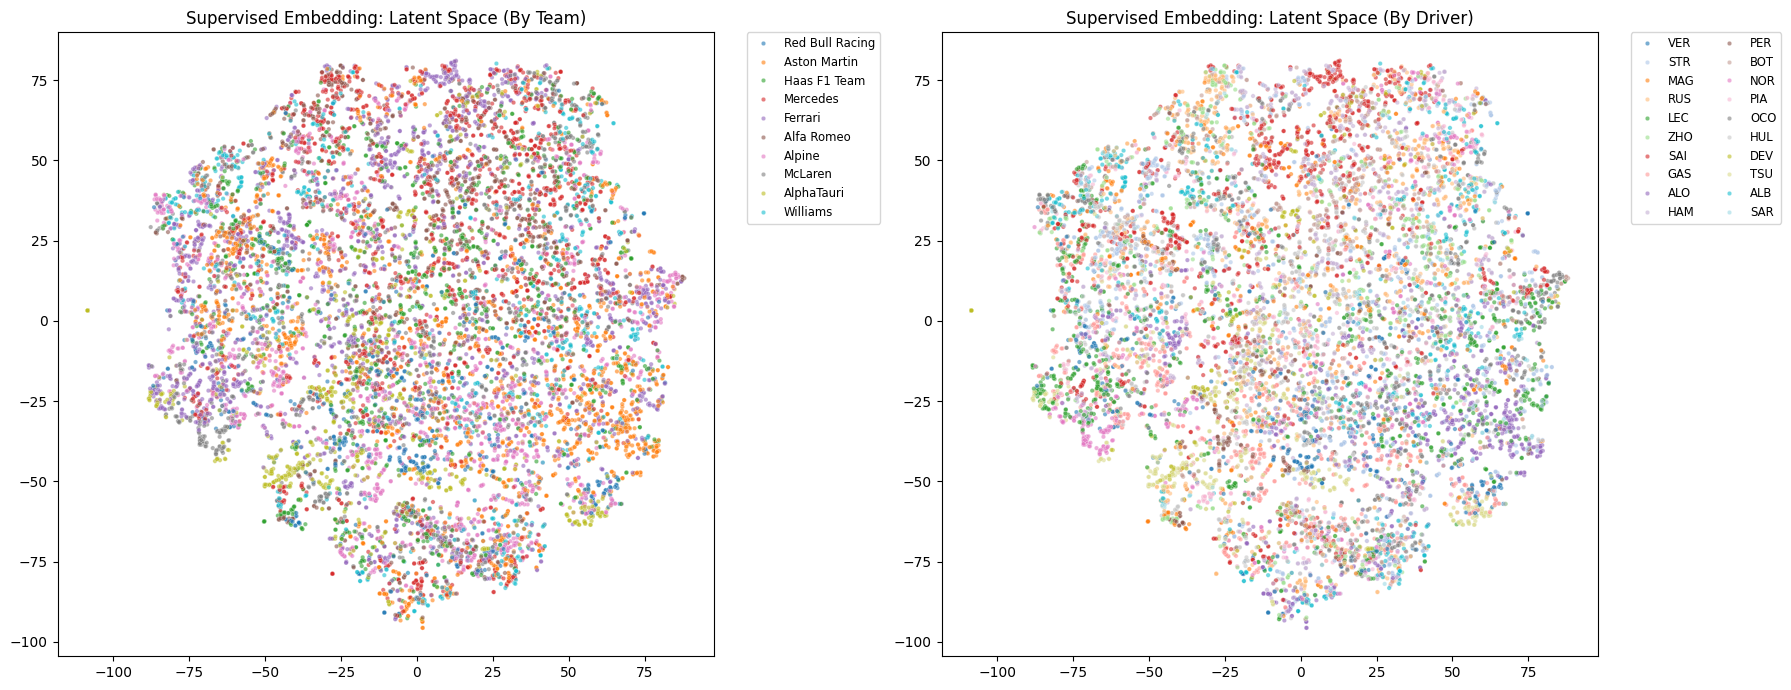


[3] Adversarial Probing
   Team probe accuracy (should be LOW if disentangled): 0.325
   Driver probe accuracy (should be HIGH if style retained): 0.316


In [ ]:
# Run Analysis
run_comprehensive_analysis("Supervised Embedding", embedder_sup, full_dataset, teams, drivers)

## **5.5. Model 3:** Learning Latent Embeddings via Conditional VAE with Adversarial Team Head

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# ==========================================
# 0. Load 2022–2024 NPZ DATA
# ==========================================
data = np.load("f1_2022_2024_data.npz", allow_pickle=True)

X_all = data["X"]       # shape: (N_laps, W, T, F)  OR (N_windows, T, F) depending on pipeline
C_all = data["C"]       # team one-hot
y_all = data["y"]       # driver index
teams = data["teams"]   # array of team names (len = NUM_TEAMS)
drivers = data["drivers"]  # array of driver names (len = NUM_DRIVERS)

print("Loaded from NPZ:")
print("  X_all.shape:", X_all.shape)
print("  C_all.shape:", C_all.shape)
print("  y_all.shape:", y_all.shape)
print("  #teams:", len(teams))
print("  #drivers:", len(drivers))

# Base dataset (no batching/padding yet)
full_dataset = tf.data.Dataset.from_tensor_slices((X_all, C_all, y_all))


# ==========================================
# 1. Gradient Reversal
# ==========================================
class GradientReversal(layers.Layer):
    def __init__(self, lambd=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambd = lambd

    def call(self, x):
        lambd = self.lambd

        @tf.custom_gradient
        def _reverse(x):
            def grad(dy):
                return -lambd * dy
            return x, grad

        return _reverse(x)


# ==========================================
# 2. Semi-Supervised Adversarial CVAE
# ==========================================
class SemiSupervisedCVAE(Model):
    def __init__(
        self,
        seq_len,
        feature_dim,
        num_teams,
        num_drivers,
        latent_dim=10,
        cond_dim=8,
        gamma=10.0,
        lambda_adv=1.0,
        beta_init=1.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.seq_len = seq_len
        self.feature_dim = feature_dim
        self.num_teams = num_teams
        self.num_drivers = num_drivers
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim
        self.gamma = gamma
        self.lambda_adv = lambda_adv

        # KL weight (will be set by BetaWarmupCallback)
        self.beta = tf.Variable(
            beta_init, trainable=False, dtype=tf.float32, name="beta"
        )

        # ---------------- Encoder: x -> (z_mean, z_log_var) ----------------
        x_in = layers.Input(shape=(seq_len, feature_dim), name="x_in")

        h = layers.Conv1D(32, 3, strides=2, padding="same", activation="relu")(x_in)
        h = layers.Conv1D(64, 3, strides=2, padding="same", activation="relu")(h)
        h = layers.Flatten()(h)
        h = layers.Dense(128, activation="relu")(h)

        z_mean = layers.Dense(latent_dim, name="z_mean")(h)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

        self.encoder = Model(x_in, [z_mean, z_log_var], name="encoder")

        # ---------------- Decoder: (z, c) -> x_hat ----------------
        z_in = layers.Input(shape=(latent_dim,), name="z_in")
        c_dec_in = layers.Input(shape=(num_teams,), name="c_dec_in")

        c_dec_emb = layers.Dense(cond_dim, activation="relu")(c_dec_in)
        dec_in = layers.Concatenate()([z_in, c_dec_emb])

        initial_len = seq_len // 4  # assumes seq_len divisible by 4
        h_dec = layers.Dense(initial_len * 64, activation="relu")(dec_in)
        h_dec = layers.Reshape((initial_len, 64))(h_dec)

        h_dec = layers.Conv1DTranspose(
            64, 3, strides=2, padding="same", activation="relu"
        )(h_dec)
        h_dec = layers.Conv1DTranspose(
            32, 3, strides=2, padding="same", activation="relu"
        )(h_dec)

        x_out = layers.Conv1D(
            feature_dim,
            3,
            padding="same",
            activation="sigmoid",
            name="x_recon",
        )(h_dec)

        self.decoder = Model([z_in, c_dec_in], x_out, name="decoder")

        # ---------------- Driver classifier: (z, c) -> driver logits --------
        z_cls_in = layers.Input(shape=(latent_dim,), name="z_for_driver")
        c_cls_in = layers.Input(shape=(num_teams,), name="c_for_driver")

        c_cls_emb = layers.Dense(cond_dim, activation="relu")(c_cls_in)
        cls_in = layers.Concatenate()([z_cls_in, c_cls_emb])

        h_cls = layers.Dense(64, activation="relu")(cls_in)
        d_logits = layers.Dense(
            num_drivers, activation="softmax", name="driver_logits"
        )(h_cls)

        self.driver_classifier = Model(
            [z_cls_in, c_cls_in],
            d_logits,
            name="driver_classifier",
        )

        # ---------------- Adversarial team classifier: GRL(z) -> team -------
        z_team_in = layers.Input(shape=(latent_dim,), name="z_for_team")
        grl = GradientReversal(lambd=lambda_adv, name="grad_reverse")(z_team_in)
        h_team = layers.Dense(32, activation="relu")(grl)
        t_logits = layers.Dense(
            num_teams, activation="softmax", name="team_logits"
        )(h_team)

        self.team_classifier = Model(
            z_team_in,
            t_logits,
            name="team_classifier",
        )

        # ---------------- Metrics ----------------
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.class_loss_tracker = tf.keras.metrics.Mean(name="class_loss")
        self.team_loss_tracker = tf.keras.metrics.Mean(name="team_loss")

        self.driver_acc = tf.keras.metrics.SparseCategoricalAccuracy(name="driver_acc")
        self.team_acc = tf.keras.metrics.CategoricalAccuracy(name="team_acc")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
            self.class_loss_tracker,
            self.team_loss_tracker,
            self.driver_acc,
            self.team_acc,
        ]

    def _sample_z(self, z_mean, z_log_var):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def _flatten_windows(self, x, c, d):
        """
        Handle both:
          x: (B, T, F)
          x: (B, W, T, F) with matching c,d shapes:
             c: (B, num_teams)      or (B, W, num_teams)
             d: (B,)                or (B, W)
        We always output:
          x_flat: (B*W, T, F) or (B, T, F)
          c_flat: (B*W, num_teams)
          d_flat: (B*W,) or (B,)
        """
        x_rank = x.shape.rank

        # ----- Case 1: already (B, T, F) -----
        if x_rank == 3:
            # Ensure c is (B, num_teams)
            if c.shape.rank == 3:
                c = c[:, 0, :]
            # Ensure d is (B,)
            if d.shape.rank == 2:
                d = d[:, 0]
            return x, c, d

        # ----- Case 2: (B, W, T, F) -----
        elif x_rank == 4:
            B = tf.shape(x)[0]
            W = tf.shape(x)[1]
            T = self.seq_len
            F = self.feature_dim

            # Flatten x
            x_flat = tf.reshape(x, [B * W, T, F])

            # Handle c
            c_rank = c.shape.rank
            if c_rank == 2:
                c_flat = tf.repeat(c, repeats=W, axis=0)
            elif c_rank == 3:
                c_flat = tf.reshape(c, [B * W, self.num_teams])
            else:
                raise ValueError(f"Unexpected c rank {c_rank}, shape={c.shape}")

            # Handle d
            d_rank = d.shape.rank
            if d_rank == 1:
                d_flat = tf.repeat(d, repeats=W, axis=0)
            elif d_rank == 2:
                d_flat = tf.reshape(d, [B * W])
            else:
                raise ValueError(f"Unexpected d rank {d_rank}, shape={d.shape}")

            return x_flat, c_flat, d_flat

        else:
            raise ValueError(f"Unexpected x rank {x_rank}, shape={x.shape}")

    # Convenience: model([x, c]) -> x_hat for already-flattened x
    def call(self, inputs, training=False):
        x, c = inputs
        z_mean, z_log_var = self.encoder(x, training=training)
        z = self._sample_z(z_mean, z_log_var)
        x_hat = self.decoder([z, c], training=training)
        return x_hat

    def train_step(self, data):
        x_raw, c_raw, d_raw = data
        x, c, d = self._flatten_windows(x_raw, c_raw, d_raw)

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(x, training=True)
            z = self._sample_z(z_mean, z_log_var)

            x_hat = self.decoder([z, c], training=True)
            d_pred = self.driver_classifier([z, c], training=True)
            t_pred = self.team_classifier(z, training=True)

            # Reconstruction loss (MSE)
            recon_per_ex = tf.reduce_sum(tf.square(x - x_hat), axis=[1, 2])
            recon_loss = tf.reduce_mean(recon_per_ex)

            # KL
            kl_per_ex = -0.5 * tf.reduce_sum(
                1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1,
            )
            kl_loss = tf.reduce_mean(kl_per_ex)

            # Driver supervision
            class_loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(d, d_pred)
            )

            # Adversarial team supervision
            team_loss = tf.reduce_mean(
                tf.keras.losses.categorical_crossentropy(c, t_pred)
            )

            total_loss = (
                recon_loss
                + self.beta * kl_loss
                + self.gamma * class_loss
                + self.lambda_adv * team_loss
            )

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.class_loss_tracker.update_state(class_loss)
        self.team_loss_tracker.update_state(team_loss)

        self.driver_acc.update_state(d, d_pred)
        self.team_acc.update_state(c, t_pred)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result(),
            "team_loss": self.team_loss_tracker.result(),
            "driver_acc": self.driver_acc.result(),
            "team_acc": self.team_acc.result(),
            "beta": self.beta,
        }

    def test_step(self, data):
        x_raw, c_raw, d_raw = data
        x, c, d = self._flatten_windows(x_raw, c_raw, d_raw)

        z_mean, z_log_var = self.encoder(x, training=False)
        z = self._sample_z(z_mean, z_log_var)

        x_hat = self.decoder([z, c], training=False)
        d_pred = self.driver_classifier([z, c], training=False)
        t_pred = self.team_classifier(z, training=False)

        recon_per_ex = tf.reduce_sum(tf.square(x - x_hat), axis=[1, 2])
        recon_loss = tf.reduce_mean(recon_per_ex)

        kl_per_ex = -0.5 * tf.reduce_sum(
            1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1,
        )
        kl_loss = tf.reduce_mean(kl_per_ex)

        class_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(d, d_pred)
        )

        team_loss = tf.reduce_mean(
            tf.keras.losses.categorical_crossentropy(c, t_pred)
        )

        total_loss = (
            recon_loss
            + self.beta * kl_loss
            + self.gamma * class_loss
            + self.lambda_adv * team_loss
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.class_loss_tracker.update_state(class_loss)
        self.team_loss_tracker.update_state(team_loss)

        self.driver_acc.update_state(d, d_pred)
        self.team_acc.update_state(c, t_pred)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "class_loss": self.class_loss_tracker.result(),
            "team_loss": self.team_loss_tracker.result(),
            "driver_acc": self.driver_acc.result(),
            "team_acc": self.team_acc.result(),
            "beta": self.beta,
        }


# ==========================================
# 3. Beta warmup callback
# ==========================================
class BetaWarmupCallback(tf.keras.callbacks.Callback):
    def __init__(self, max_beta=2.0, warmup_epochs=20):
        super().__init__()
        self.max_beta = max_beta
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            new_beta = self.max_beta * float(epoch + 1) / float(self.warmup_epochs)
        else:
            new_beta = self.max_beta
        self.model.beta.assign(new_beta)
        tf.print("Epoch", epoch, "- setting beta to", new_beta)


# ==========================================
# 4. Infer shapes from 3-year dataset
# ==========================================
for sample_x, sample_c, sample_y in full_dataset.take(1):
    x_shape = sample_x.shape.as_list()
    c_shape = sample_c.shape.as_list()
    y_shape = sample_y.shape.as_list()

print("Raw sample_x.shape:", x_shape)
print("Raw sample_c.shape:", c_shape)
print("Raw sample_y.shape:", y_shape)

# x is (W, T, F) or (T, F). We want seq_len = T, feature_dim = F
if len(x_shape) == 3:      # (W, T, F) case
    SEQ_LEN = x_shape[1]
    FEATURE_DIM = x_shape[2]
elif len(x_shape) == 2:    # (T, F) case
    SEQ_LEN = x_shape[0]
    FEATURE_DIM = x_shape[1]
else:
    raise ValueError(f"Unexpected x_shape {x_shape}")

NUM_TEAMS = c_shape[-1]     # last dim always num_teams
NUM_DRIVERS = len(drivers)  # from NPZ metadata

print("SEQ_LEN:", SEQ_LEN)
print("FEATURE_DIM:", FEATURE_DIM)
print("NUM_TEAMS:", NUM_TEAMS)
print("NUM_DRIVERS:", NUM_DRIVERS)

# --------- Build padded_batch shapes ---------
# x: (W, T, F) -> (batch, W_max, T, F)
#    (T, F)    -> (batch, T, F)
if len(x_shape) == 3:
    x_padded_shape = [None, SEQ_LEN, FEATURE_DIM]
elif len(x_shape) == 2:
    x_padded_shape = [SEQ_LEN, FEATURE_DIM]

# c:
#   (num_teams,)       → rank 1
#   (W, num_teams)     → rank 2
if len(c_shape) == 1:
    c_padded_shape = [NUM_TEAMS]
elif len(c_shape) == 2:
    c_padded_shape = [None, NUM_TEAMS]
else:
    raise ValueError(f"Unexpected c shape {c_shape}")

# y:
#   ()     → scalar driver id per example
#   (W,)   → driver id per window
if len(y_shape) == 0:
    y_padded_shape = []
elif len(y_shape) == 1:
    y_padded_shape = [None]
else:
    raise ValueError(f"Unexpected y shape {y_shape}")

print("padded_shapes for x:", x_padded_shape)
print("padded_shapes for c:", c_padded_shape)
print("padded_shapes for y:", y_padded_shape)


# ==========================================
# 5. Dataset pipeline with padded_batch
# ==========================================
BATCH_SIZE = 256
SHUFFLE_BUFFER = 100_000
EPOCHS = 50

train_ds = (
    full_dataset
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            x_padded_shape,
            c_padded_shape,
            y_padded_shape,
        ),
        drop_remainder=False,
    )
    .prefetch(tf.data.AUTOTUNE)
)


# ==========================================
# 6. Instantiate & train the CVAE (3-year data)
# ==========================================
model_cvae = SemiSupervisedCVAE(
    seq_len=SEQ_LEN,
    feature_dim=FEATURE_DIM,
    num_teams=NUM_TEAMS,
    num_drivers=NUM_DRIVERS,
    latent_dim=10,
    cond_dim=8,
    gamma=10.0,
    lambda_adv=1.0,
    beta_init=0.0,
)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_cvae.compile(optimizer=optimizer)

beta_callback = BetaWarmupCallback(
    max_beta=2.0,
    warmup_epochs=20,
)

history = model_cvae.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=[beta_callback],
)


# ==========================================
# 7. Embedding extraction helper (unchanged logic)
# ==========================================
def extract_embeddings(encoder, dataset, batch_size=1024):
    """
    encoder: Keras Model, encoder(x) -> [z_mean, z_log_var]
    dataset: tf.data.Dataset yielding (x, c, y)
       x: (W, T, F) variable W
       c: (num_teams,) or (W, num_teams)
       y: scalar or (W,)
    Returns:
        Z: (N, latent_dim)
        driver_labels: (N,)
        team_onehot: (N, num_teams)
    """
    # Peek one element to get shapes
    for sample_x, sample_c, sample_y in dataset.take(1):
        x_shape = sample_x.shape.as_list()
        c_shape = sample_c.shape.as_list()
        y_shape = sample_y.shape.as_list()
    T = x_shape[-2]   # works for both (T,F) and (W,T,F)
    F = x_shape[-1]
    NUM_TEAMS = c_shape[-1]

    # Build padded shapes same as in training
    if len(x_shape) == 3:
        x_padded_shape = [None, T, F]
    elif len(x_shape) == 2:
        x_padded_shape = [T, F]
    else:
        raise ValueError(f"Unexpected x shape {x_shape}")

    if len(c_shape) == 1:
        c_padded_shape = [NUM_TEAMS]
    elif len(c_shape) == 2:
        c_padded_shape = [None, NUM_TEAMS]
    else:
        raise ValueError(f"Unexpected c shape {c_shape}")

    if len(y_shape) == 0:
        y_padded_shape = []
    elif len(y_shape) == 1:
        y_padded_shape = [None]
    else:
        raise ValueError(f"Unexpected y shape {y_shape}")

    all_z, all_y, all_c = [], [], []

    batched_ds = dataset.padded_batch(
        batch_size,
        padded_shapes=(x_padded_shape, c_padded_shape, y_padded_shape),
        drop_remainder=False,
    )

    for x_batch, c_batch, y_batch in batched_ds:
        # x_batch: (B, W_max, T, F) or (B, T, F)
        # c_batch: (B, num_teams) or (B, W_max, num_teams)
        # y_batch: (B,) or (B, W_max)

        if x_batch.shape.rank == 4:
            B = tf.shape(x_batch)[0]
            W = tf.shape(x_batch)[1]
            x_flat = tf.reshape(x_batch, [B * W, T, F])
        elif x_batch.shape.rank == 3:
            # already (B, T, F)
            B = tf.shape(x_batch)[0]
            W = 1
            x_flat = x_batch
        else:
            raise ValueError(f"Unexpected x_batch shape {x_batch.shape}")

        c_rank = c_batch.shape.rank
        if c_rank == 2:
            # (B, num_teams) -> repeat over W windows
            c_flat = tf.repeat(c_batch, repeats=W, axis=0)
        elif c_rank == 3:
            # (B, W_max, num_teams) -> flatten
            c_flat = tf.reshape(c_batch, [-1, NUM_TEAMS])
        else:
            raise ValueError(f"Unexpected c_batch rank {c_rank}, shape {c_batch.shape}")

        y_rank = y_batch.shape.rank
        if y_rank == 1:
            # (B,) -> repeat over W windows
            y_flat = tf.repeat(y_batch, repeats=W, axis=0)
        elif y_rank == 2:
            # (B, W_max) -> flatten
            y_flat = tf.reshape(y_batch, [-1])
        else:
            raise ValueError(f"Unexpected y_batch rank {y_rank}, shape {y_batch.shape}")

        z_mean, z_log_var = encoder(x_flat, training=False)
        z_batch = z_mean.numpy()

        all_z.append(z_batch)
        all_y.append(y_flat.numpy())
        all_c.append(c_flat.numpy())

    Z = np.concatenate(all_z, axis=0)
    driver_labels = np.concatenate(all_y, axis=0)
    team_onehot = np.concatenate(all_c, axis=0)
    return Z, driver_labels, team_onehot

Loaded from NPZ:
  X_all.shape: (415041, 100, 5)
  C_all.shape: (415041, 12)
  y_all.shape: (415041,)
  #teams: 12
  #drivers: 28
Raw sample_x.shape: [100, 5]
Raw sample_c.shape: [12]
Raw sample_y.shape: []
SEQ_LEN: 100
FEATURE_DIM: 5
NUM_TEAMS: 12
NUM_DRIVERS: 28
padded_shapes for x: [100, 5]
padded_shapes for c: [12]
padded_shapes for y: []
Epoch 0 - setting beta to 0.1
Epoch 1/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - beta: 0.1000 - class_loss: 1.6921 - driver_acc: 0.3883 - kl_loss: 19.3154 - loss: 35.1323 - recon_loss: 13.8740 - team_acc: 0.1275 - team_loss: 2.4063
Epoch 1 - setting beta to 0.2
Epoch 2/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - beta: 0.2000 - class_loss: 0.8414 - driver_acc: 0.5298 - kl_loss: 15.4297 - loss: 16.8616 - recon_loss: 3.0594 - team_acc: 0.1558 - team_loss: 2.3023
Epoch 2 - setting beta to 0.3
Epoch 3/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - beta: 0.3000 - class_loss: 0.8161 - driver_acc: 0.5519 - kl_loss: 12.9072 - loss: 17.6107 - 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import distance
import tensorflow as tf


def run_comprehensive_analysis(model_type, embedder, dataset, team_names, driver_names,
                               batch_size=256, max_batches=200):
    print(f"\n=== ANALYSIS REPORT: {model_type} ===")

    # 1. Data Extraction
    print("Extracting Embeddings...")
    Z_list, y_team_list, y_driver_list = [], [], []

    # ✅ Batch the dataset so encoder sees (B, 100, 5), not (100, 5)
    analysis_ds = dataset.batch(batch_size).take(max_batches)

    for batch in analysis_ds:
        # Unpack based on structure
        if len(batch) == 2:      # ((x, c), y)
            (x, c), y = batch
        elif len(batch) == 3:    # (x, c, y)
            x, c, y = batch
        else:
            raise ValueError(f"Unexpected batch structure length: {len(batch)}")

        # ---------- Encoder forward pass ----------
        # For this model, the encoder takes ONLY x: encoder(x) -> [z_mean, z_log_var]
        outputs = embedder(x, training=False)

        # Handle output format (CVAE returns [z_mean, z_log_var])
        if isinstance(outputs, (list, tuple)):
            z = outputs[0]  # z_mean
        else:
            z = outputs     # plain embedding

        # ---------- Labels ----------
        c_np = c.numpy()
        y_np = y.numpy()

        # Teams: c is one-hot of shape (B, num_teams)
        if c_np.ndim == 2:
            t_idx = np.argmax(c_np, axis=1)
        elif c_np.ndim == 1:
            # rare fallback: (num_teams,) → single example
            t_idx = np.array([np.argmax(c_np)])
        else:
            raise ValueError(f"Unexpected c ndim {c_np.ndim}, shape={c_np.shape}")

        # Drivers: y is (B,) of integer ids
        if y_np.ndim == 1:
            d_idx = y_np
        elif y_np.ndim == 0:
            d_idx = np.array([y_np])
        else:
            raise ValueError(f"Unexpected y ndim {y_np.ndim}, shape={y_np.shape}")

        Z_list.append(z.numpy())
        y_team_list.append(t_idx)
        y_driver_list.append(d_idx)

    Z = np.concatenate(Z_list, axis=0)
    y_team = np.concatenate(y_team_list, axis=0)
    y_driver = np.concatenate(y_driver_list, axis=0)

    print(f"Extracted {len(Z)} vectors. Latent Dim: {Z.shape[1]}")

    # 2. Driver Distances (Centroids)
    print("\n[1] Inter-Driver Distances (Centroid L2)")
    unique_drivers = np.unique(y_driver)
    centroids = {d: np.mean(Z[y_driver == d], axis=0) for d in unique_drivers}

    pairs = [('VER', 'HAM'), ('VER', 'PER'), ('HAM', 'BOT')]
    d_map = {name: i for i, name in enumerate(driver_names)}

    for d1_name, d2_name in pairs:
        if d1_name in d_map and d2_name in d_map:
            idx1, idx2 = d_map[d1_name], d_map[d2_name]
            if idx1 in centroids and idx2 in centroids:
                dist = distance.euclidean(centroids[idx1], centroids[idx2])
                print(f"    d({d1_name}, {d2_name}) = {dist:.4f}")

    # 3. t-SNE Visualization
    print("\n[2] Generating t-SNE Plots...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    Z_tsne = tsne.fit_transform(Z)

    plt.figure(figsize=(18, 7))

    # Color by Team
    plt.subplot(1, 2, 1)
    team_labels = [team_names[i] for i in y_team]
    sns.scatterplot(x=Z_tsne[:, 0], y=Z_tsne[:, 1],
                    hue=team_labels, palette='tab10',
                    s=10, alpha=0.6)
    plt.title(f"{model_type}: Latent Space (By Team)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0, fontsize='small')

    # Color by Driver
    plt.subplot(1, 2, 2)
    driver_labels = [driver_names[i] for i in y_driver]
    sns.scatterplot(x=Z_tsne[:, 0], y=Z_tsne[:, 1],
                    hue=driver_labels, palette='tab20',
                    s=10, alpha=0.6)
    plt.title(f"{model_type}: Latent Space (By Driver)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0, fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

    # 4. Adversarial Probing
    print("\n[3] Adversarial Probing")

    # Probe 1: Predict TEAM
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_team, test_size=0.3, random_state=42
    )
    clf_team = LogisticRegression(max_iter=2000)
    clf_team.fit(X_train, y_train)
    acc_team = accuracy_score(y_test, clf_team.predict(X_test))
    print(f"   Team probe accuracy (should be LOW if disentangled): {acc_team:.3f}")

    # Probe 2: Predict DRIVER
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_driver, test_size=0.3, random_state=42
    )
    clf_driver = LogisticRegression(max_iter=2000)
    clf_driver.fit(X_train, y_train)
    acc_driver = accuracy_score(y_test, clf_driver.predict(X_test))
    print(f"   Driver probe accuracy (should be HIGH if style retained): {acc_driver:.3f}")


=== ANALYSIS REPORT: Style-Disentangled CVAE ===
Extracting Embeddings...
Extracted 51200 vectors. Latent Dim: 10

[1] Inter-Driver Distances (Centroid L2)
    d(VER, HAM) = 0.1446
    d(VER, PER) = 0.1542
    d(HAM, BOT) = 0.0933

[2] Generating t-SNE Plots...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


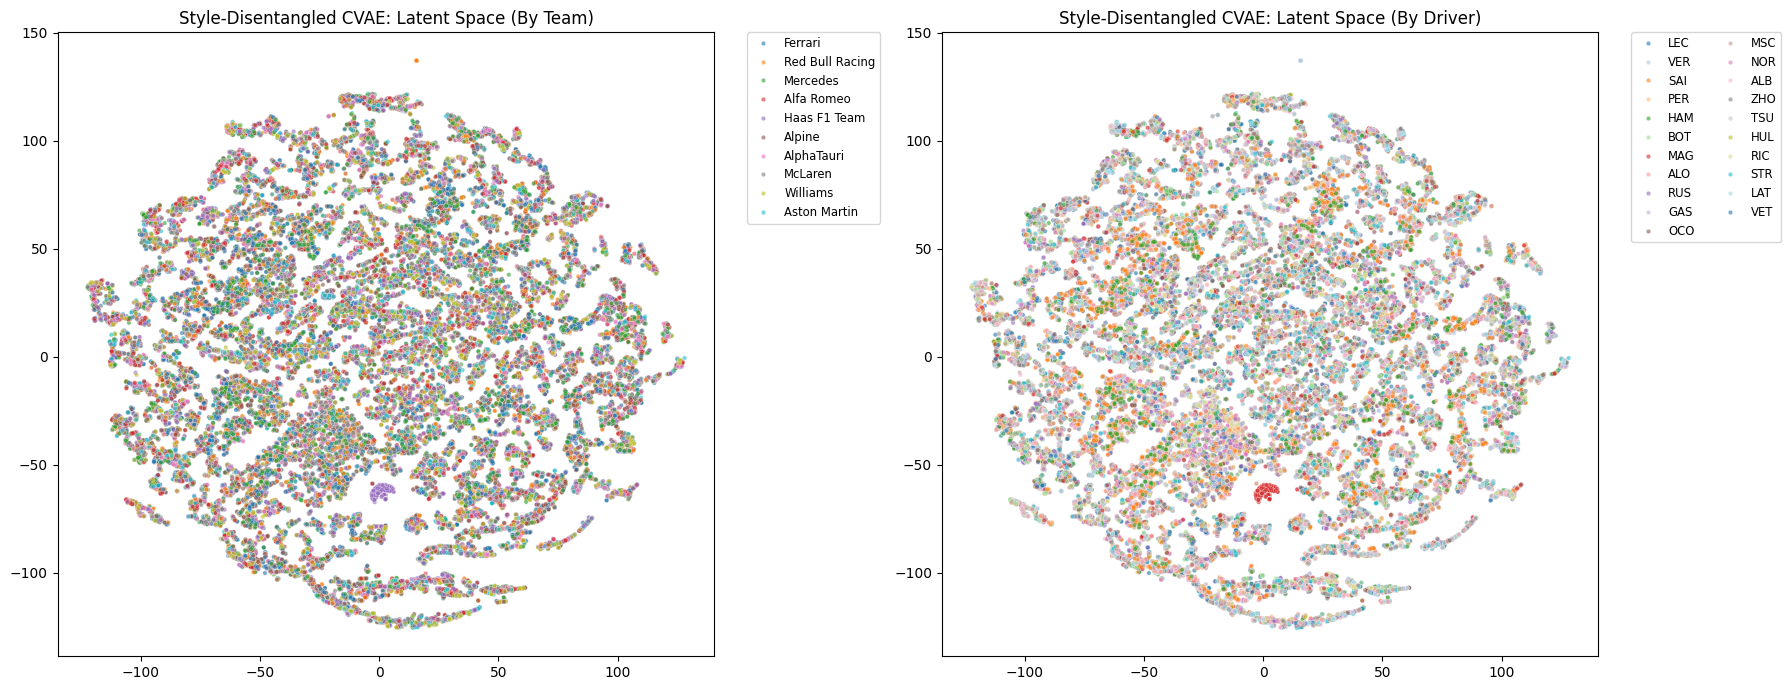


[3] Adversarial Probing
   Team probe accuracy (should be LOW if disentangled): 0.151
   Driver probe accuracy (should be HIGH if style retained): 0.084


In [6]:
run_comprehensive_analysis(
    model_type="Style-Disentangled CVAE",
    embedder=model_cvae.encoder,
    dataset=full_dataset,
    team_names=teams,
    driver_names=drivers,
)